In [2]:
import tensorflow as tf
import os
import warnings
import logging
import sys
import pandas as pd
import yaml
import subprocess
from pathlib import Path
from IPython.display import Image, display

project_root = os.getcwd()
os.environ["PYTHONPATH"] = project_root
print(f"PYTHONPATH set to: {project_root}")

!python -m spacy download en_core_web_sm

2026-08-22 21:37:15.343206: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/janek/Projekty/Sentiment/.venv/lib/python3.12/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


PYTHONPATH set to: /home/janek/Projekty/Sentiment
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 6.6 MB/s  0:00:01 eta 0:00:01

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [2]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# Print all words
print(list(ENGLISH_STOP_WORDS))
print(len(ENGLISH_STOP_WORDS))

['seemed', 'something', 'hereafter', 'against', 'anyone', 'at', 'very', 'become', 'four', 'hers', 'inc', 'has', 'wherein', 'she', 'formerly', 'that', 'ten', 'again', 'which', 'whoever', 'a', 'down', 'their', 'hereby', 'thin', 'where', 'before', 'two', 'then', 'its', 'about', 'why', 'ie', 'former', 'name', 'the', 'moreover', 'nevertheless', 'who', 'though', 'thence', 'somewhere', 'after', 'you', 'sometime', 'top', 'however', 'out', 'toward', 'eg', 'due', 'front', 'although', 'mostly', 'thus', 'by', 'now', 'whereafter', 'between', 'across', 'fire', 'to', 'more', 'anyhow', 'too', 'find', 'perhaps', 'back', 'de', 'enough', 'well', 'already', 'bill', 'con', 'somehow', 'many', 'detail', 'everything', 'some', 'what', 'while', 'get', 'beside', 'he', 'whole', 'third', 'up', 'sometimes', 'either', 'anywhere', 'becoming', 'co', 'twenty', 'might', 'other', 'here', 'whereupon', 'never', 're', 'latterly', 'hundred', 'yourselves', 'behind', 'itself', 'call', 'nobody', 'describe', 'another', 'whose', 

In [3]:
import pandas as pd
import numpy as np
from IPython.display import display

def pokaz_wyniki_mcnemara(csv_path, p_threshold=0.05, base_caption="McNemar test", representation="rep",
                          baseline_model_name="name",  text="txt", add_baseline_row=True):
    try:
        df_results = pd.read_csv(csv_path)

        # --- 1. Prepare Numerical Columns ---
        df_results['P_Value_Num'] = pd.to_numeric(df_results['P_Value'], errors='coerce')
        if 'Acc_Baseline' in df_results.columns:
            df_results['Acc_Baseline'] = pd.to_numeric(df_results['Acc_Baseline'], errors='coerce')
        df_results['Acc_Model'] = pd.to_numeric(df_results['Acc_Model'], errors='coerce')

        # Identify Baseline
        baseline_mask = df_results['P_Value'].astype(str).str.strip().str.lower() == "baseline"
        
        # Get baseline accuracy
        baseline_acc = None
        if 'Acc_Baseline' in df_results.columns:
            baseline_vals = df_results['Acc_Baseline'].dropna()
            if not baseline_vals.empty:
                baseline_acc = baseline_vals.iloc[0]

        # Handle missing baseline row
        if not baseline_mask.any() and baseline_acc is not None and add_baseline_row:
            baseline_candidate = df_results[df_results['Acc_Model'] == baseline_acc]
            if not baseline_candidate.empty:
                df_results.loc[baseline_candidate.index[0], 'P_Value'] = 'Baseline'
            else:
                baseline_row = pd.Series(index=df_results.columns, dtype=object)
                baseline_row['Text'], baseline_row['Representation'], baseline_row['Model'] = text, representation, baseline_model_name
                baseline_row['Acc_Model'], baseline_row['P_Value'], baseline_row['P_Value_Num'] = baseline_acc, 'Baseline', np.nan
                df_results = pd.concat([pd.DataFrame([baseline_row]), df_results], ignore_index=True)
            
            baseline_mask = df_results['P_Value'].astype(str).str.strip().str.lower() == "baseline"

        # --- 2. Logic: Significance and Arrows ---
        # A row is significant if p < threshold OR it is the baseline
        is_significant = (df_results['P_Value_Num'] < p_threshold)
        
        if baseline_acc is not None:
            # Arrows ONLY if (Significant) AND (Not Baseline)
            df_results['Better'] = np.where(
                (is_significant) & (~baseline_mask),
                np.where(df_results['Acc_Model'] > baseline_acc, '↑',
                         np.where(df_results['Acc_Model'] < baseline_acc, '↓', '—')),
                '' # Empty if not significant or if it is the baseline
            )
        else:
            df_results['Better'] = ''

        # --- 3. Sorting (Baseline is NOT forced to top) ---
        df_sig_block = df_results[is_significant | baseline_mask].copy()
        df_nonsig_block = df_results[~is_significant & ~baseline_mask].copy()

        df_sig_block = df_sig_block.sort_values(by='Acc_Model', ascending=False)
        df_nonsig_block = df_nonsig_block.sort_values(by='Acc_Model', ascending=False)

        df_final = pd.concat([df_sig_block, df_nonsig_block]).reset_index(drop=True)

        # --- 4. Formatting for Display & LaTeX ---
        cols_to_show = ['Text', 'Representation', 'Model', 'Acc_Model', 'Better', 'P_Value']
        df_html = df_final[cols_to_show].copy()

        # HTML Display
        styled_df = (df_html.style
                     .format({"Acc_Model": "{:.2%}", "P_Value": lambda x: x if isinstance(x, str) else f"{x:.6f}"})
                     .set_caption(f"McNemar test {base_caption}"))
        display(styled_df)

        # --- LaTeX Generation ---
        df_latex = df_final[cols_to_show + ['P_Value_Num']].copy()
        df_latex['Acc_Model'] = df_latex['Acc_Model'].apply(lambda x: f"{x:.2%}".replace('%', r'\%'))
        df_latex['P_Value'] = df_latex['P_Value'].apply(lambda x: x if isinstance(x, str) else f"{x:.6f}")

        # Arrow replacement
        df_latex['Better'] = df_latex['Better'].replace({'↑': r'$\uparrow$', '↓': r'$\downarrow$', '—': r'$-$', '': ''})

        # Bolding logic
        final_baseline_mask = df_latex['P_Value'].astype(str).str.lower() == "baseline"
        final_sig_mask = (df_latex['P_Value_Num'] < p_threshold) | final_baseline_mask

        for col in cols_to_show:
            df_latex.loc[final_sig_mask, col] = r'\textbf{' + df_latex.loc[final_sig_mask, col].astype(str) + r'}'

        # Index bolding
        df_latex.index = [r'\textbf{' + str(i) + r'}' if s else str(i) for i, s in zip(df_latex.index, final_sig_mask)]
        df_latex.drop(columns=['P_Value_Num'], inplace=True)
        
        # Column formatting and tags
        df_latex.rename(columns={'Acc_Model': 'ACC_MODEL_TAG', 'P_Value': 'P_VALUE_TAG', 'Better': 'BETTER_TAG'}, inplace=True)
        col_format = "llllrc" if 'BETTER_TAG' in df_latex.columns else "llllr"
        col_format += "c"

        latex_code = df_latex.style.to_latex(hrules=True, column_format=col_format, position="htbp", 
                                            caption=base_caption.replace('%', r'\%'), label="tab:McNemar")

        # Post-processing: Add \centering and Fix midrules
        latex_code = latex_code.replace('\\begin{table}[htbp]', '\\begin{table}[htbp]\n    \\centering')
        latex_code = latex_code.replace('ACC_MODEL_TAG', '$Acc_{Model}$').replace('P_VALUE_TAG', '$p$-value').replace('BETTER_TAG', r'$\uparrow$/$\downarrow$')
        
        # Insert \midrule between significant and non-significant blocks
        lines = latex_code.split('\n')
        output_lines = []
        sig_done = False
        for line in lines:
            if '&' in line and r'\textbf{' not in line.split('&')[0] and not sig_done:
                sig_done = True
            output_lines.append(line)
        
        print("\n--- Kod LaTeX ---\n" + '\n'.join(output_lines))

    except Exception as e:
        print(f"Error: {e}")

In [19]:
subprocess.run(["python", "-m", "scripts.loader"], check=True)

2026-03-12 13:34:25.065593: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/janek/Projekty/Sentiment/.venv/lib/python3.12/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):
I0000 00:00:1773318870.269936    4189 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3584 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6
2026-03-12 13:34:30.556306: I tensorflow/core/kernels/data/tf_record_dataset_op.cc:396] The default buffer size is 262144, which is overridden by the user specified `buffer_size` of 8388608
2026-03-12 13:34:37.603377:

Loading IMDb reviews...
Removed 418 duplicates.
Processing 49582 reviews...


100%|██████████| 49582/49582 [05:23<00:00, 153.14it/s]


Train: 24791, Val: 17353, Test: 7438
Saved train set to data/preprocessed/train.parquet
Saved val set to data/preprocessed/val.parquet
Saved test set to data/preprocessed/test.parquet


CompletedProcess(args=['python', '-m', 'scripts.loader'], returncode=0)

In [28]:
def preview_parquet_compact(filepath, n=2, text_chars=200, token_items=30):
    df = pd.read_parquet(filepath)

    print(f"File: {filepath}")
    print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")

    df_sample = df.head(n)

    for col in df_sample.columns:
        print("=" * 60)
        print(f"COLUMN: {col}")
        print("=" * 60)

        for i, val in enumerate(df_sample[col]):
            print(f"--- Row {i} ---")

            # Handle long text
            if isinstance(val, str):
                preview = val[:text_chars]
                if len(val) > text_chars:
                    preview += " ..."
                print(preview)

            # Handle token arrays / lists
            elif isinstance(val, (list, tuple)) or hasattr(val, "__array__"):
                tokens = list(val)
                preview = tokens[:token_items]
                print(" ".join(preview))

                if len(tokens) > token_items:
                    print(f"... ({len(tokens)-token_items} more tokens)")

            else:
                print(val)

            print()


preview_parquet_compact('data/preprocessed/train.parquet', n=2)

File: data/preprocessed/train.parquet
Shape: 24791 rows, 10 columns

COLUMN: sentiment
--- Row 0 ---
1

--- Row 1 ---
0

COLUMN: text_raw
--- Row 0 ---
I first saw this one when it was first shown, so I'm not too objective about it. It really managed to scare me, partly because it was so late at night, but partly because of that whole feeling from a  ...

--- Row 1 ---
I first watched Kindred in 1987 along with another movie called devouring waves. I remember back then i hated them both and i have never really bothered to watch them again.<br /><br />However i have  ...

COLUMN: text_clean
--- Row 0 ---
I first saw this one when it was first shown, so I'm not too objective about it. It really managed to scare me, partly because it was so late at night, but partly because of that whole feeling from a  ...

--- Row 1 ---
I first watched Kindred in 1987 along with another movie called devouring waves. I remember back then i hated them both and i have never really bothered to watch them ag

In [18]:
import pandas as pd

def preview_text(filepath, n=20):
    # Loading the file
    df = pd.read_parquet(filepath)

    print(f"File: {filepath}")
    print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")

    df_filtered = df[df["sentiment"] == 0].head(n)
    
    # Check if we actually found any rows
    if df_filtered.empty:
        print("No rows found with selected sentiment.")
        return

    for col in ["sentiment", "text_raw"]:
        if col not in df_filtered.columns:
            continue
            
        print("=" * 60)
        print(f"COLUMN: {col}")
        print("=" * 60)

        for i, val in enumerate(df_filtered[col]):
            print(f"--- Row {i} (Original Index: {df_filtered.index[i]}) ---")
            print(f"{val}\n")

preview_text('data/preprocessed/train.parquet', n=1)

File: data/preprocessed/train.parquet
Shape: 24791 rows, 10 columns

COLUMN: sentiment
--- Row 0 (Original Index: 1) ---
0

COLUMN: text_raw
--- Row 0 (Original Index: 1) ---
I first watched Kindred in 1987 along with another movie called devouring waves. I remember back then i hated them both and i have never really bothered to watch them again.<br /><br />However i have recently started a crusade to collect as many 80's horror titles in their original boxed form, That have been deleted for some time. I have got myself quite a proud collection with many more titles on my list!<br /><br />The Kindred although i have not as yet got a copy is high priority as all the old movies i didn't like back then, I now own and have now re-watched and think they are brilliant and the bits i do remember of the Kindred are now driving me to want to get hold of a copy A.S.A.P.<br /><br />Hurray for the 80's and long live horror!



In [34]:
!python -m scripts.run_basic

Training & evaluating: 100%|████████████████████████████████████████| 16/16 [02:44<00:00, 10.26s/it]


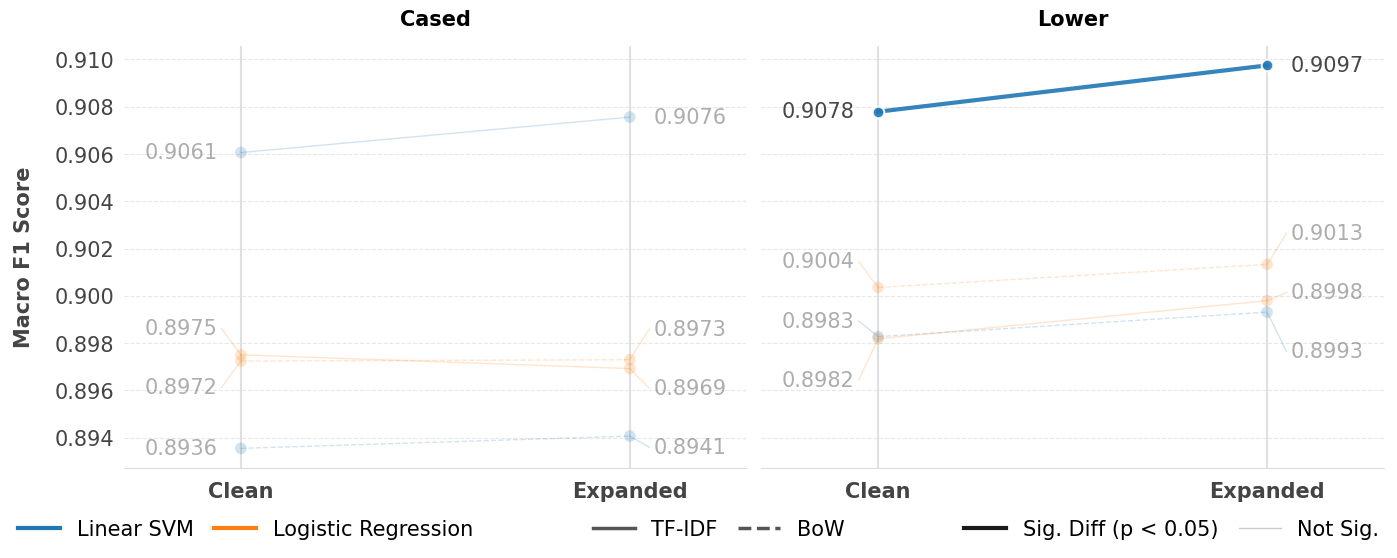

In [35]:
import itertools
from pathlib import Path
from typing import List
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from statsmodels.stats.contingency_tables import mcnemar

# --- Konfiguracja ---
MODELS = {"linear_svm": "Linear SVM", "logreg": "LogReg"}
TEXT_VERSIONS = ["text_clean", "text_expanded"]
CASINGS = ["cased", "lower"]
REPRESENTATIONS = ["BoW", "TF-IDF"]

COLOR_MAP = {"Linear SVM": "#1f77b4", "LogReg": "#ff7f0e"}
LINESTYLE_MAP = {"TF-IDF": "-", "BoW": "--"}


def load_predictions(filepath: Path) -> np.ndarray:
    """Wczytuje surowe predykcje (0/1) z pliku z logitami."""
    df = pd.read_csv(filepath)
    return (df['probability'] > 0.5).astype(int).values

def get_true_labels(filepath: Path) -> np.ndarray:
    """Wczytuje ground truth."""
    return pd.read_csv(filepath)['true_label'].values

def adjust_y_positions(ys: List[float], threshold: float = 0.0025) -> np.ndarray:
    """Zapobiega nakładaniu się etykiet na osi Y."""
    ys = np.array(ys)
    indices = np.argsort(ys)
    adjusted = ys.copy()

    for _ in range(50):
        for i in range(len(adjusted) - 1):
            idx1, idx2 = indices[i], indices[i + 1]
            diff = adjusted[idx2] - adjusted[idx1]
            if diff < threshold:
                push = (threshold - diff) / 2.0
                adjusted[idx1] -= push
                adjusted[idx2] += push
    return adjusted

def load_and_test_data(reports_dir: Path, predictions_dir: Path) -> pd.DataFrame:
    """
    Wczytuje F1-score z raportów oraz oblicza istotność statystyczną
    zmiany (Clean vs Expanded) używając surowych predykcji.
    """
    records = []
    
    # Przechodzimy przez wszystkie kombinacje z wyłączeniem wersji tekstu
    # (chcemy porównać clean vs expanded dla każdej kombinacji)
    combinations = itertools.product(MODELS.items(), CASINGS, REPRESENTATIONS)

    for (model_key, model_label), case, rep in combinations:
        
        # --- Zbieranie danych o "text_clean" ---
        f1_clean_path = reports_dir / f"text_clean_{case}_{rep}_{model_key}.csv"
        pred_clean_path = predictions_dir / f"text_clean_{case}_{rep}_{model_key}.csv"
        
        # --- Zbieranie danych o "text_expanded" ---
        f1_exp_path = reports_dir / f"text_expanded_{case}_{rep}_{model_key}.csv"
        pred_exp_path = predictions_dir / f"text_expanded_{case}_{rep}_{model_key}.csv"

        # Upewniamy się, że oba modele z pary istnieją
        if all(p.exists() for p in [f1_clean_path, pred_clean_path, f1_exp_path, pred_exp_path]):
            
            # 1. Wczytanie F1
            f1_clean = pd.read_csv(f1_clean_path, index_col=0).loc["macro avg", "f1-score"]
            f1_exp = pd.read_csv(f1_exp_path, index_col=0).loc["macro avg", "f1-score"]
            
            # 2. Test statystyczny
            y_true = get_true_labels(pred_clean_path)
            preds_clean = load_predictions(pred_clean_path)
            preds_exp = load_predictions(pred_exp_path)
            
            both_correct = np.sum((preds_clean == y_true) & (preds_exp == y_true))
            clean_only = np.sum((preds_clean == y_true) & (preds_exp != y_true))
            exp_only = np.sum((preds_clean != y_true) & (preds_exp == y_true))
            both_wrong = np.sum((preds_clean != y_true) & (preds_exp != y_true))
            
            table = [[both_correct, clean_only], [exp_only, both_wrong]]
            p_value = mcnemar(table, exact=False, correction=True).pvalue
            is_significant = p_value < 0.05
            
            # 3. Zapis do struktury
            pipeline_name = f"{model_label} ({rep})"
            records.append({
                "Pipeline": pipeline_name,
                "Model": model_label,
                "Representation": rep,
                "Casing": case,
                "F1_Clean": f1_clean,
                "F1_Expanded": f1_exp,
                "P_Value": p_value,
                "Significant": is_significant
            })

    return pd.DataFrame(records)


def create_slopegraph_significant(df: pd.DataFrame, fontsize: float):
    """Generuje slopegraph podświetlający tylko istotne statystycznie zmiany."""
    if df.empty:
        print("DataFrame is empty!")
        return

    cased_df = df[df["Casing"] == "cased"].copy()
    lower_df = df[df["Casing"] == "lower"].copy()

    all_f1 = pd.concat([df["F1_Clean"], df["F1_Expanded"]])
    padding = 0.05 * (all_f1.max() - all_f1.min())
    y_limits = (all_f1.min() - padding, all_f1.max() + padding)

    plt.rcParams['font.family'] = 'sans-serif'
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True, facecolor='white')
    titles = ["Cased", "Lower"]

    for ax, ax_df, title in zip(axes, [cased_df, lower_df], titles):
        _setup_axis(ax, title, y_limits, fontsize)
        _draw_significant_lines(ax, ax_df, fontsize)

    _add_legend_and_titles(fig, fontsize)
    plt.tight_layout(rect=[0, 0.05, 1, 0.92])
    plt.savefig("results/figures/analysis/casing-effect-slopegraph.png", dpi=300, bbox_inches="tight")
    plt.show()


def _setup_axis(ax: plt.Axes, title: str, y_limits: tuple, fontsize: float):
    ax.set_facecolor('white')
    ax.set_title(title, fontsize=fontsize, fontweight='bold', pad=15)
    ax.set_xlim(-0.3, 1.3)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Clean", "Expanded"], fontsize=fontsize, fontweight='bold', color="#444444")
    ax.tick_params(axis='x', length=0, pad=10)
    ax.tick_params(axis='y', left=False, labelsize=fontsize, colors="#444444")
    ax.set_ylim(y_limits)
    ax.yaxis.grid(True, linestyle='--', alpha=0.3)
    ax.set_axisbelow(True)

    for spine in ['top', 'right', 'left']:
        ax.spines[spine].set_visible(False)
    ax.spines['bottom'].set_color('#DDDDDD')
    ax.axvline(0, color='#E0E0E0', lw=1.5, zorder=1)
    ax.axvline(1, color='#E0E0E0', lw=1.5, zorder=1)


def _draw_significant_lines(ax: plt.Axes, df: pd.DataFrame, fontsize: float):
    clean_vals = df["F1_Clean"].tolist()
    expanded_vals = df["F1_Expanded"].tolist()

    clean_adj = adjust_y_positions(clean_vals)
    expanded_adj = adjust_y_positions(expanded_vals)

    for i, (_, row) in enumerate(df.iterrows()):
        y_c = row["F1_Clean"]
        y_e = row["F1_Expanded"]
        c = COLOR_MAP[row["Model"]]
        ls = LINESTYLE_MAP[row["Representation"]]
        is_sig = row["Significant"]

        # LOGIKA WIZUALNA: Jeśli nieistotne -> wyszarzamy i ścieńciamy
        alpha_val = 0.9 if is_sig else 0.2
        lw_val = 3.0 if is_sig else 1.0
        marker_edge = 'white' if is_sig else 'none'

        ax.plot([0, 1], [y_c, y_e], color=c, linestyle=ls, lw=lw_val, alpha=alpha_val, zorder=2)
        ax.scatter([0, 1], [y_c, y_e], color=c, s=70, edgecolor=marker_edge, linewidth=1.5, alpha=alpha_val, zorder=4)

        # Lewa etykieta
        if abs(clean_adj[i] - y_c) > 0.0001:
            ax.plot([0, -0.05], [y_c, clean_adj[i]], color=c, lw=1, alpha=0.2, zorder=1)
        ax.text(-0.06, clean_adj[i], f"{y_c:.4f}", ha='right', va='center',
                fontsize=fontsize, color='#333333', alpha=max(0.4, alpha_val), fontweight='500', zorder=5)

        # Prawa etykieta
        if abs(expanded_adj[i] - y_e) > 0.0001:
            ax.plot([1, 1.05], [y_e, expanded_adj[i]], color=c, lw=1, alpha=0.2, zorder=1)
        ax.text(1.06, expanded_adj[i], f"{y_e:.4f}", ha='left', va='center',
                fontsize=fontsize, color='#333333', alpha=max(0.4, alpha_val), fontweight='500', zorder=5)


def _add_legend_and_titles(fig: plt.Figure, fontsize: float):
    fig.axes[0].set_ylabel("Macro F1 Score", fontsize=fontsize, labelpad=15, fontweight='bold', color="#444444")

    legend_elements = [
        Line2D([0], [0], color=COLOR_MAP['Linear SVM'], lw=3, label='Linear SVM'),
        Line2D([0], [0], color=COLOR_MAP['LogReg'], lw=3, label='Logistic Regression'),
        Line2D([], [], color='none', label='   '), 
        Line2D([0], [0], color='#555555', lw=2.5, linestyle='-', label='TF-IDF'),
        Line2D([0], [0], color='#555555', lw=2.5, linestyle='--', label='BoW'),
        Line2D([], [], color='none', label='   '),
        # Informacja o statystyce do legendy
        Line2D([0], [0], color='black', lw=3, alpha=0.9, label='Sig. Diff (p < 0.05)'),
        Line2D([0], [0], color='black', lw=1, alpha=0.2, label='Not Sig.')
    ]

    fig.legend(handles=legend_elements, loc='lower center', ncol=8, 
               frameon=False, fontsize=fontsize, bbox_to_anchor=(0.5, -0.02), columnspacing=1.0)

if __name__ == "__main__":
    reports = Path("results/val/run_basic/classification_reports")
    predictions = Path("results/val/run_basic/raw_predictions")

    if not reports.exists() or not predictions.exists():
        print(f"Could not find required directories.")
    else:
        df = load_and_test_data(reports, predictions)
        if df.empty:
            print("No matching experiment files found!")
        else:
            create_slopegraph_significant(df, 15)

# SVM (TF-IDF)

In [36]:
!python -m scripts.run_statistical_test \
    --targets "run_basic:text_expanded_cased_TF-IDF_linear=Expanded and Cased | TF-IDF | SVM" \
              "run_basic:text_clean_cased_BoW_linear=Cased | BoW | SVM" \
              "run_basic:text_clean_cased_TF-IDF_log=Cased | TF-IDF | LogReg" \
              "run_basic:text_clean_lower_TF-IDF_linear_svm=Lower | TF-IDF | SVM" \
    --baseline val/run_basic/raw_predictions/text_clean_cased_TF-IDF_linear_svm.csv \
    --output basic_clean_cased_svm_mcnemar_raport.csv

pokaz_wyniki_mcnemara(
    "results/analysis/basic_clean_cased_svm_mcnemar_raport.csv", 0.05, "McNemar Test (Experiment 1 - a)", "TF-IDF", "SVM", "Cased"
)

!python -m scripts.run_statistical_test \
    --targets "run_basic:text_expanded_lower_TF-IDF_lin=Expanded and Lower | TF-IDF | SVM" \
              "run_basic:text_clean_lower_BoW_linear=Lower | BoW | SVM" \
              "run_basic:text_clean_lower_TF-IDF_log=Lower | TF-IDF | LogReg" \
              "run_basic:text_clean_cased_TF-IDF_lin=Cased | TF-IDF | SVM" \
    --baseline val/run_basic/raw_predictions/text_clean_lower_TF-IDF_linear_svm.csv \
    --output basic_clean_lower_svm_mcnemar_raport.csv

pokaz_wyniki_mcnemara(
    "results/analysis/basic_clean_lower_svm_mcnemar_raport.csv", 0.05, "McNemar Test (Experiment 1 - b)", "TF-IDF", "SVM", "Lower"
)

,Text,Representation,Model,Acc_Model,Better,P_Value
0,Cased,TF-IDF,SVM,90.61%,,Baseline
1,Cased,TF-IDF,LogReg,89.75%,↓,0.000000
2,Cased,BoW,SVM,89.36%,↓,0.000000
3,Lower,TF-IDF,SVM,90.78%,,0.164879
4,Expanded and Cased,TF-IDF,SVM,90.76%,,0.112399



--- Kod LaTeX ---
\begin{table}[htbp]
    \centering
\caption{McNemar Test (Experiment 1 - a)}
\label{tab:McNemar}
\begin{tabular}{llllrcc}
\toprule
 & Text & Representation & Model & $Acc_{Model}$ & $\uparrow$/$\downarrow$ & $p$-value \\
\midrule
\textbf{0} & \textbf{Cased} & \textbf{TF-IDF} & \textbf{SVM} & \textbf{90.61\%} & \textbf{} & \textbf{Baseline} \\
\textbf{1} & \textbf{Cased} & \textbf{TF-IDF} & \textbf{LogReg} & \textbf{89.75\%} & \textbf{$\downarrow$} & \textbf{0.000000} \\
\textbf{2} & \textbf{Cased} & \textbf{BoW} & \textbf{SVM} & \textbf{89.36\%} & \textbf{$\downarrow$} & \textbf{0.000000} \\
3 & Lower & TF-IDF & SVM & 90.78\% &  & 0.164879 \\
4 & Expanded and Cased & TF-IDF & SVM & 90.76\% &  & 0.112399 \\
\bottomrule
\end{tabular}
\end{table}



,Text,Representation,Model,Acc_Model,Better,P_Value
0,Expanded and Lower,TF-IDF,SVM,90.98%,↑,0.036879
1,Lower,TF-IDF,SVM,90.78%,,Baseline
2,Lower,BoW,SVM,89.83%,↓,0.000000
3,Lower,TF-IDF,LogReg,89.82%,↓,0.000000
4,Cased,TF-IDF,SVM,90.61%,,0.164879



--- Kod LaTeX ---
\begin{table}[htbp]
    \centering
\caption{McNemar Test (Experiment 1 - b)}
\label{tab:McNemar}
\begin{tabular}{llllrcc}
\toprule
 & Text & Representation & Model & $Acc_{Model}$ & $\uparrow$/$\downarrow$ & $p$-value \\
\midrule
\textbf{0} & \textbf{Expanded and Lower} & \textbf{TF-IDF} & \textbf{SVM} & \textbf{90.98\%} & \textbf{$\uparrow$} & \textbf{0.036879} \\
\textbf{1} & \textbf{Lower} & \textbf{TF-IDF} & \textbf{SVM} & \textbf{90.78\%} & \textbf{} & \textbf{Baseline} \\
\textbf{2} & \textbf{Lower} & \textbf{BoW} & \textbf{SVM} & \textbf{89.83\%} & \textbf{$\downarrow$} & \textbf{0.000000} \\
\textbf{3} & \textbf{Lower} & \textbf{TF-IDF} & \textbf{LogReg} & \textbf{89.82\%} & \textbf{$\downarrow$} & \textbf{0.000000} \\
4 & Cased & TF-IDF & SVM & 90.61\% &  & 0.164879 \\
\bottomrule
\end{tabular}
\end{table}



- For SVM TF-IDF is generally bettern than BoW
- SVM is generally better than LogReg
- In case of lowered letters - expansion improves the result

# LogReg (TF-IDF)

In [37]:
!python -m scripts.run_statistical_test \
    --targets "run_basic:text_expanded_cased_TF-IDF_log=Expanded and Cased | TF-IDF | LogReg" \
              "run_basic:text_clean_cased_BoW_log=Cased | BoW | LogReg" \
              "run_basic:text_clean_cased_TF-IDF_lin=Cased | TF-IDF | SVM" \
              "run_basic:text_clean_lower_TF-IDF_log=Lower | TF-IDF | LogReg" \
    --baseline val/run_basic/raw_predictions/text_clean_cased_TF-IDF_logreg.csv \
    --output basic_clean_cased_log_mcnemar_raport.csv

pokaz_wyniki_mcnemara("results/analysis/basic_clean_cased_log_mcnemar_raport.csv", 0.05, "McNemar Test (Experiment 1 - c)", "TF-IDF", "LogReg", "Cased")

!python -m scripts.run_statistical_test \
    --targets "run_basic:text_expanded_lower_TF-IDF_log=Expanded and Lower | TF-IDF | LogReg" \
              "run_basic:text_clean_lower_BoW_log=Lower | Bow | LogReg" \
              "run_basic:text_clean_lower_TF-IDF_lin=Lower|TF-IDF|SVM" \
              "run_basic:text_clean_cased_TF-IDF_log=Cased|TF-IDF|LogReg" \
    --baseline val/run_basic/raw_predictions/text_clean_lower_TF-IDF_logreg.csv \
    --output basic_clean_lower_logreg_mcnemar_raport.csv

pokaz_wyniki_mcnemara("results/analysis/basic_clean_lower_logreg_mcnemar_raport.csv", 0.05, "McNemar Test (Experiment 1 - d)", "TF-IDF", "LogReg", "Lower")

,Text,Representation,Model,Acc_Model,Better,P_Value
0,Cased,TF-IDF,SVM,90.61%,↑,0.000000
1,Cased,TF-IDF,LogReg,89.75%,,Baseline
2,Lower,TF-IDF,LogReg,89.82%,,0.546041
3,Cased,BoW,LogReg,89.73%,,0.898788
4,Expanded and Cased,TF-IDF,LogReg,89.70%,,0.513802



--- Kod LaTeX ---
\begin{table}[htbp]
    \centering
\caption{McNemar Test (Experiment 1 - c)}
\label{tab:McNemar}
\begin{tabular}{llllrcc}
\toprule
 & Text & Representation & Model & $Acc_{Model}$ & $\uparrow$/$\downarrow$ & $p$-value \\
\midrule
\textbf{0} & \textbf{Cased} & \textbf{TF-IDF} & \textbf{SVM} & \textbf{90.61\%} & \textbf{$\uparrow$} & \textbf{0.000000} \\
\textbf{1} & \textbf{Cased} & \textbf{TF-IDF} & \textbf{LogReg} & \textbf{89.75\%} & \textbf{} & \textbf{Baseline} \\
2 & Lower & TF-IDF & LogReg & 89.82\% &  & 0.546041 \\
3 & Cased & BoW & LogReg & 89.73\% &  & 0.898788 \\
4 & Expanded and Cased & TF-IDF & LogReg & 89.70\% &  & 0.513802 \\
\bottomrule
\end{tabular}
\end{table}



,Text,Representation,Model,Acc_Model,Better,P_Value
0,Lower,TF-IDF,SVM,90.78%,↑,0.000000
1,Lower,TF-IDF,LogReg,89.82%,,Baseline
2,Lower,Bow,LogReg,90.04%,,0.242561
3,Expanded and Lower,TF-IDF,LogReg,89.98%,,0.053784
4,Cased,TF-IDF,LogReg,89.75%,,0.546041



--- Kod LaTeX ---
\begin{table}[htbp]
    \centering
\caption{McNemar Test (Experiment 1 - d)}
\label{tab:McNemar}
\begin{tabular}{llllrcc}
\toprule
 & Text & Representation & Model & $Acc_{Model}$ & $\uparrow$/$\downarrow$ & $p$-value \\
\midrule
\textbf{0} & \textbf{Lower} & \textbf{TF-IDF} & \textbf{SVM} & \textbf{90.78\%} & \textbf{$\uparrow$} & \textbf{0.000000} \\
\textbf{1} & \textbf{Lower} & \textbf{TF-IDF} & \textbf{LogReg} & \textbf{89.82\%} & \textbf{} & \textbf{Baseline} \\
2 & Lower & Bow & LogReg & 90.04\% &  & 0.242561 \\
3 & Expanded and Lower & TF-IDF & LogReg & 89.98\% &  & 0.053784 \\
4 & Cased & TF-IDF & LogReg & 89.75\% &  & 0.546041 \\
\bottomrule
\end{tabular}
\end{table}



- For LogReg TF-IDF we can only see that SVM performs better

In [38]:
!python -m scripts.run_on_preprocessing

Training & evaluating:  17%|██████▊                                  | 4/24 [01:53<05:45, 17.27s/it]/home/janek/Projekty/Sentiment/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
Training & evaluating:  50%|████████████████████                    | 12/24 [05:13<02:09, 10.82s/it]/home/janek/Projekty/Sentiment/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/janek/Projekty/Sentiment/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
Training & evaluating:  67%|██████████████████████████▋             | 16/24 [08:25<03:10, 23.77s/it]/home/janek/Projekty/Sentiment/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Li

In [39]:
!python -m scripts.run_custom

Feature Variants:   3%|█▌                                           | 4/120 [01:49<32:05, 16.60s/it]/home/janek/Projekty/Sentiment/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
Feature Variants:  17%|███████▎                                    | 20/120 [08:11<19:05, 11.45s/it]/home/janek/Projekty/Sentiment/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
Feature Variants:  20%|████████▊                                   | 24/120 [10:44<31:10, 19.49s/it]/home/janek/Projekty/Sentiment/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/janek/Projekty/Sentiment/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Li

In [40]:
!python -m scripts.visualize_custom_filtering --column tokens_lower
!python -m scripts.visualize_custom_filtering --column tokens_filtered

Loading data for visualization...
Vectorizing text for 'tokens_lower'
Calculating Z-scores on the Custom matrix...

Generating WordClouds individually (DPI=300)...
Saved: /home/janek/Projekty/Sentiment/results/figures/analysis/tokens_lower_positive_wordcloud.pdf  →  caption: "Extracted positive words (total kept: 19172)"
Saved: /home/janek/Projekty/Sentiment/results/figures/analysis/tokens_lower_neutral_wordcloud.pdf  →  caption: "Extracted neutral words (total discarded: 102665)"
Saved: /home/janek/Projekty/Sentiment/results/figures/analysis/tokens_lower_negative_wordcloud.pdf  →  caption: "Extracted negative words (total kept: 17178)"

All three wordclouds saved successfully (DPI=300).
Loading data for visualization...
Vectorizing text for 'tokens_filtered'
Calculating Z-scores on the Custom matrix...

Generating WordClouds individually (DPI=300)...
Saved: /home/janek/Projekty/Sentiment/results/figures/analysis/tokens_filtered_positive_wordcloud.pdf  →  caption: "Extracted positive w

In [41]:
from IPython.display import IFrame

def draw_pdfs(size=400):
    print("Lower")
    display(IFrame("results/figures/analysis/tokens_lower_positive_wordcloud.pdf", width=size, height=size))
    display(IFrame("results/figures/analysis/tokens_lower_neutral_wordcloud.pdf", width=size, height=size))
    display(IFrame("results/figures/analysis/tokens_lower_negative_wordcloud.pdf", width=size, height=size))
    print("Filtered")
    display(IFrame("results/figures/analysis/tokens_lower_positive_wordcloud.pdf", width=size, height=size))
    display(IFrame("results/figures/analysis/tokens_lower_neutral_wordcloud.pdf", width=size, height=size))
    display(IFrame("results/figures/analysis/tokens_lower_negative_wordcloud.pdf", width=size, height=size))

draw_pdfs()

Lower


Filtered



BEST CONFIGURATION
----------------------------------------
Top Model:           Linear SVM
Feature Variant:     CustomTfidf
Top Preprocessing:   Stemmed
Optimal Z-Score:     2.0
Peak Macro F1-Score: 0.9141
----------------------------------------

Top 5 Runs Overall:


,Token Processing,Variant,Z-Score Threshold,Model,Macro F1-Score
94,Stemmed,CustomTfidf,2.0,Linear SVM,0.914125
114,Lemmatized,CustomTfidf,2.0,Linear SVM,0.913663
110,Lemmatized,CustomTfidf,0.0,Linear SVM,0.913606
34,Lower,CustomTfidf,2.0,Linear SVM,0.913434
32,Lower,CustomTfidf,1.0,Linear SVM,0.913378


Saved polished plot to: results/figures/zscore_threshold.png


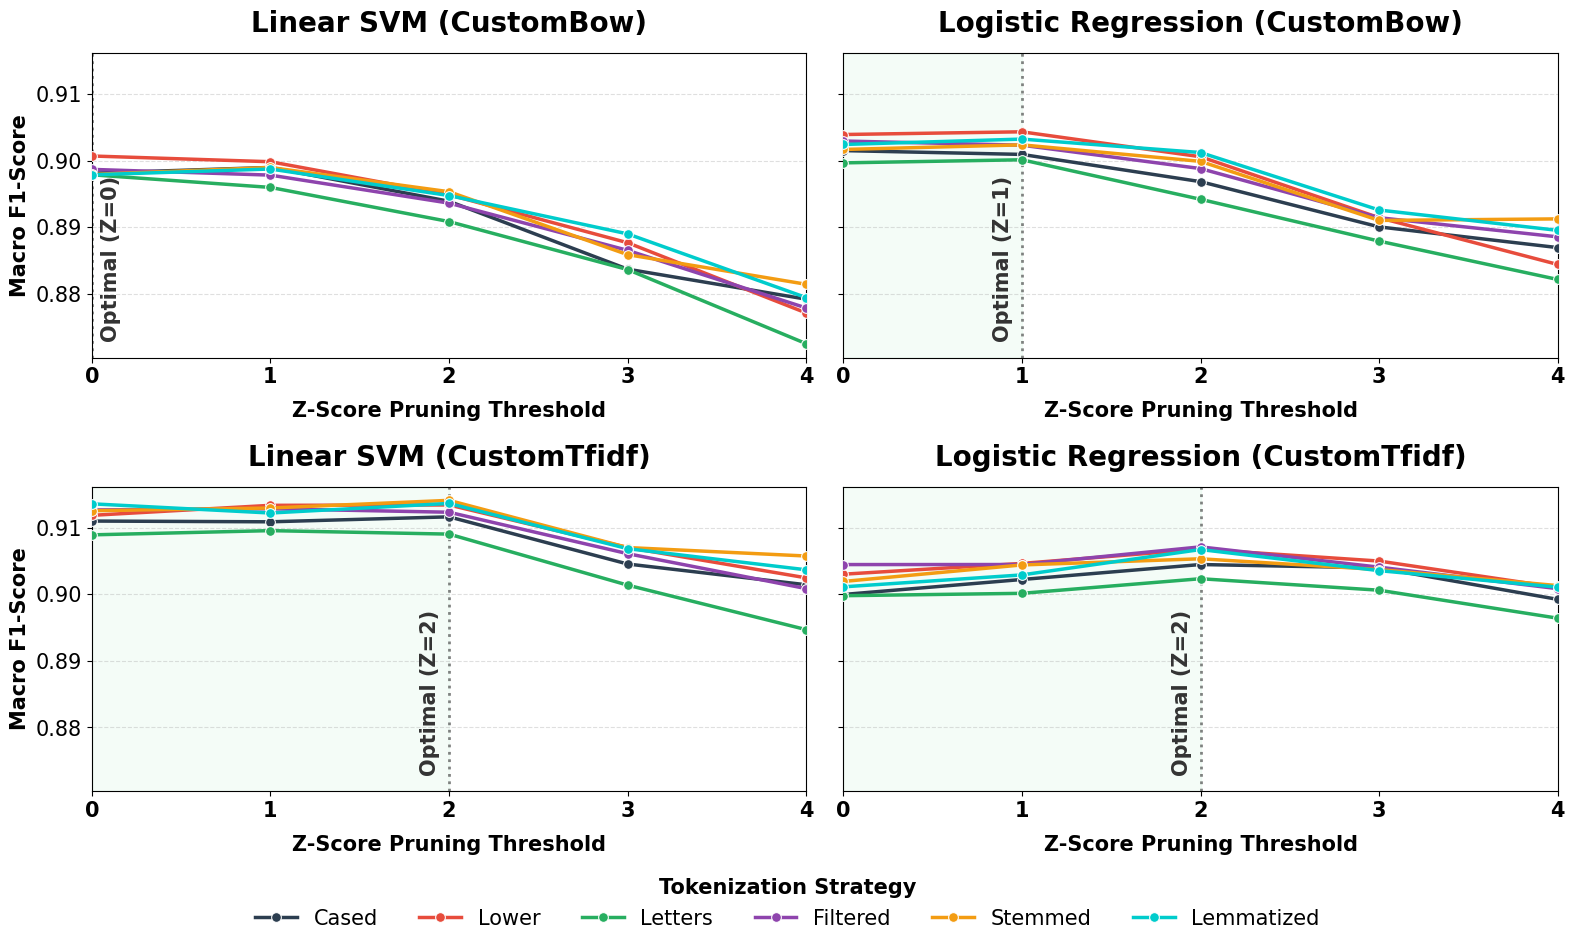

In [70]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import gc

def plot_zscore_experiment_polished(reports_dir="results/val/run_custom/classification_reports"):
    fontsize = 15
    reports_path = Path(reports_dir)

    if not reports_path.exists():
        print(f"Could not find directory: {reports_path}")
        return

    # Configuration
    token_columns = [
        'tokens_cased', 'tokens_lower', 'tokens_letters',
        'tokens_filtered', 'tokens_stemmed', 'tokens_lemmatized'
    ]

    models = {"linear_svm": "Linear SVM", "logreg": "Logistic Regression"}
    variants = ["CustomBow", "CustomTfidf"]

    z_scores = [0, 1, 2, 3, 4]
    records = []

    # Extract Data
    for token_col in token_columns:
        for variant in variants:
            for z in z_scores:
                for model_key, model_label in models.items():

                    filename = f"{token_col}_{variant}_Z{z}_{model_key}.csv"
                    filepath = reports_path / filename

                    if filepath.exists():
                        df = pd.read_csv(filepath, index_col=0)

                        records.append({
                            "Token Processing": token_col.replace('tokens_', '').title(),
                            "Variant": variant,
                            "Z-Score Threshold": float(z),
                            "Model": model_label,
                            "Macro F1-Score": df.loc["macro avg", "f1-score"]
                        })

    if not records:
        print("No matching experiment files found!")
        return

    results_df = pd.DataFrame(records)

    best_run = results_df.loc[results_df['Macro F1-Score'].idxmax()]

    print("\nBEST CONFIGURATION")
    print("-" * 40)
    print(f"Top Model:           {best_run['Model']}")
    print(f"Feature Variant:     {best_run['Variant']}")
    print(f"Top Preprocessing:   {best_run['Token Processing']}")
    print(f"Optimal Z-Score:     {best_run['Z-Score Threshold']}")
    print(f"Peak Macro F1-Score: {best_run['Macro F1-Score']:.4f}")
    print("-" * 40)

    print("\nTop 5 Runs Overall:")
    display(results_df.sort_values(by='Macro F1-Score', ascending=False).head(5))

    # --- Global font settings ---
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.size'] = fontsize          # base size for all text

    fig, axes = plt.subplots(
        2, 2,
        figsize=(16, 10),
        sharey=True
    )

    bold_palette = {
        'Cased': '#2c3e50',      # Dark Navy
        'Lower': '#e74c3c',      # Red
        'Letters': '#27ae60',    # Green
        'Filtered': '#8e44ad',   # Purple
        'Stemmed': '#f39c12',    # Orange
        'Lemmatized': '#00CCCC'  # Aqua
    }

    axes = axes.flatten()
    plot_index = 0

    # Draw Subplots
    for variant in variants:
        for model_key, model_label in models.items():

            ax = axes[plot_index]
            plot_index += 1

            ax.set_facecolor('white')

            model_df = results_df[
                (results_df["Model"] == model_label) &
                (results_df["Variant"] == variant)
            ]

            if not model_df.empty:
                # Find the Z-score that produced the highest F1
                best_z_for_subplot = model_df.loc[model_df['Macro F1-Score'].idxmax()]['Z-Score Threshold']
                ax.axvline(best_z_for_subplot, color='#333333', linestyle=':', linewidth=2, zorder=1, alpha=0.6)
                ax.axvspan(0, best_z_for_subplot, color='#2ecc71', alpha=0.05, zorder=0)

                x_offset = 0.05 if best_z_for_subplot == 0 else -0.05
                h_align = 'left' if best_z_for_subplot == 0 else 'right'

                # Annotation font size: slightly smaller than base for visual balance
                ax.text(
                    best_z_for_subplot + x_offset,  
                    0.05,
                    f'Optimal (Z={int(best_z_for_subplot)})',
                    color='#333333',
                    fontsize=fontsize,
                    fontweight='bold',
                    rotation=90,
                    transform=ax.get_xaxis_transform(),
                    ha=h_align,
                    va='bottom'
                )

            sns.lineplot(
                data=model_df,
                x="Z-Score Threshold",
                y="Macro F1-Score",
                hue="Token Processing",
                palette=bold_palette,
                marker="o",
                markersize=7,
                linewidth=2.5,
                ax=ax,
                legend=(plot_index == 1),
                zorder=3
            )

            # Titles & Axes Styling
            ax.set_title(
                f"{model_label} ({variant})",
                fontsize=fontsize+5,
                fontweight='bold',
                pad=15
            )

            ax.set_xlim(0, 4)
            ax.set_xticks([0, 1, 2, 3, 4])
            # Tick labels inherit global font.size, but keep bold
            ax.set_xticklabels(["0", "1", "2", "3", "4"], fontweight='bold')
            ax.set_xlabel("Z-Score Pruning Threshold", fontsize=fontsize, fontweight='bold', labelpad=10)

            for spine in ['top', 'right', 'left', 'bottom']:
                ax.spines[spine].set_visible(True)

            ax.grid(axis='y', linestyle='--', alpha=0.4)
            ax.grid(axis='x', visible=False)

            ax.tick_params(axis='y', labelsize=fontsize)

    # Global labels
    axes[0].set_ylabel("Macro F1-Score", fontsize=fontsize, fontweight='bold')
    axes[2].set_ylabel("Macro F1-Score", fontsize=fontsize, fontweight='bold')

    # Legend
    handles, labels = axes[0].get_legend_handles_labels()
    axes[0].get_legend().remove()

    fig.legend(
        handles,
        labels,
        loc='lower center',
        ncol=6,
        frameon=False,
        fontsize=fontsize,
        bbox_to_anchor=(0.5, -0.02),
        title="Tokenization Strategy",
        title_fontproperties={'weight': 'bold', 'size': fontsize}
    )

    plt.tight_layout(rect=[0, 0.05, 1, 0.94])

    output_dir = Path("results/figures")
    output_dir.mkdir(parents=True, exist_ok=True)
    out_path = output_dir / "zscore_threshold.png"

    plt.savefig(out_path, dpi=300, bbox_inches='tight')
    print(f"Saved polished plot to: {out_path}")

    plt.show()

    # Cleanup
    plt.close(fig)
    del records, results_df, fig, axes
    gc.collect()


if __name__ == "__main__":
    plot_zscore_experiment_polished()

In [4]:
import subprocess
from pathlib import Path

def auto_run_mcnemar(baseline, exp_folder, output_csv, filter_kws=None):
    """
    Automates running the McNemar test script by dynamically parsing filenames
    and generating the 'folder:::filename=Text|Rep|Model' target format.
    """
    preds_dir = Path(f"results/val/{exp_folder}/raw_predictions")
    targets = []
    
    if filter_kws is None:
        filter_kws = []

    for f in preds_dir.glob("*.csv"):
        # Skip if filename doesn't contain all filter keywords
        if not all(kw in f.name for kw in filter_kws):
            continue
            
        stem = f.stem
        
        # 1. Parse Model Name
        model_lbl = "SVM" if "linear_svm" in stem else "LogReg"
        clean_stem = stem.replace("_linear_svm", "").replace("_logreg", "")
        
        # 2. Parse Text Tokenization
        token_map = {
            "tokens_cased": "Tokens Cased", "tokens_lower": "Tokens Lower",
            "tokens_letters": "Tokens Letters", "tokens_filtered": "Tokens Filtered",
            "tokens_stemmed": "Tokens Stemmed", "tokens_lemmatized": "Tokens Lemmatized"
        }
        text_lbl = "Base"
        for k, v in token_map.items():
            if clean_stem.startswith(k):
                text_lbl = v
                clean_stem = clean_stem.replace(k + "_", "")
                break
                
        # 3. Parse Representation & Z-score (e.g. CustomTfidf_Z2)
        parts = clean_stem.split("_")
        if len(parts) >= 2:
            rep_lbl = f"{parts[0]} ({parts[1]})" 
        else:
            rep_lbl = clean_stem
            
        # 4. Construct the formatted target string
        target_str = f"{exp_folder}:::{stem}={text_lbl} | {rep_lbl} | {model_lbl}"
        targets.append(target_str)

    if not targets:
        print(f"No files matched the filters {filter_kws}!")
        return

    # Execute the statistical test script
    cmd = [
        "python", "-m", "scripts.run_statistical_test",
        "--baseline", baseline,
        "--output", output_csv,
        "--targets"
    ] + targets
    
    print(f"Running statistical test for {len(targets)} configurations...")
    subprocess.run(cmd, check=True)
    print(f"Done. Saved to {output_csv}")

In [44]:
# 1. Compare all Custom TF-IDF SVM models against the Baseline SVM
auto_run_mcnemar(
    baseline="val/run_basic/raw_predictions/text_expanded_lower_TF-IDF_linear_svm.csv",
    exp_folder="run_custom",
    output_csv="custom_svm_tfidf_mcnemar_raport.csv",
    filter_kws=["CustomTfidf", "linear_svm"]
)
pokaz_wyniki_mcnemara(
    "results/analysis/custom_svm_tfidf_mcnemar_raport.csv", 
    p_threshold=0.05, 
    base_caption="McNemar Test (Custom TF-IDF vs SVM Baseline)",
    representation="TF-IDF",
    baseline_model_name="SVM",
    text="Expanded and Lower"
)

Running statistical test for 30 configurations...
Done. Saved to custom_svm_tfidf_mcnemar_raport.csv


,Text,Representation,Model,Acc_Model,Better,P_Value
0,Tokens Stemmed,CustomTfidf (Z2),SVM,91.41%,↑,0.012517
1,Tokens Lemmatized,CustomTfidf (Z2),SVM,91.37%,↑,0.020340
2,Tokens Lemmatized,CustomTfidf (Z0),SVM,91.36%,↑,0.010486
3,Tokens Lower,CustomTfidf (Z2),SVM,91.34%,↑,0.026857
4,Tokens Lower,CustomTfidf (Z1),SVM,91.34%,↑,0.018008
5,Tokens Stemmed,CustomTfidf (Z1),SVM,91.30%,↑,0.049788
6,Expanded and Lower,TF-IDF,SVM,90.98%,,Baseline
7,Tokens Stemmed,CustomTfidf (Z4),SVM,90.58%,↓,0.047471
8,Tokens Cased,CustomTfidf (Z3),SVM,90.46%,↓,0.006363
9,Tokens Lemmatized,CustomTfidf (Z4),SVM,90.37%,↓,0.002455



--- Kod LaTeX ---
\begin{table}[htbp]
    \centering
\caption{McNemar Test (Custom TF-IDF vs SVM Baseline)}
\label{tab:McNemar}
\begin{tabular}{llllrcc}
\toprule
 & Text & Representation & Model & $Acc_{Model}$ & $\uparrow$/$\downarrow$ & $p$-value \\
\midrule
\textbf{0} & \textbf{Tokens Stemmed} & \textbf{CustomTfidf (Z2)} & \textbf{SVM} & \textbf{91.41\%} & \textbf{$\uparrow$} & \textbf{0.012517} \\
\textbf{1} & \textbf{Tokens Lemmatized} & \textbf{CustomTfidf (Z2)} & \textbf{SVM} & \textbf{91.37\%} & \textbf{$\uparrow$} & \textbf{0.020340} \\
\textbf{2} & \textbf{Tokens Lemmatized} & \textbf{CustomTfidf (Z0)} & \textbf{SVM} & \textbf{91.36\%} & \textbf{$\uparrow$} & \textbf{0.010486} \\
\textbf{3} & \textbf{Tokens Lower} & \textbf{CustomTfidf (Z2)} & \textbf{SVM} & \textbf{91.34\%} & \textbf{$\uparrow$} & \textbf{0.026857} \\
\textbf{4} & \textbf{Tokens Lower} & \textbf{CustomTfidf (Z1)} & \textbf{SVM} & \textbf{91.34\%} & \textbf{$\uparrow$} & \textbf{0.018008} \\
\textbf{5} & \te

In [45]:
# 2. Compare all Custom TF-IDF LogReg models against the Baseline LogReg
auto_run_mcnemar(
    baseline="val/run_basic/raw_predictions/text_expanded_lower_TF-IDF_logreg.csv",
    exp_folder="run_custom",
    output_csv="custom_logreg_tfidf_mcnemar_raport.csv",
    filter_kws=["CustomTfidf", "logreg"]
)
pokaz_wyniki_mcnemara(
    "results/analysis/custom_logreg_tfidf_mcnemar_raport.csv", 
    p_threshold=0.05, 
    base_caption="McNemar Test (Custom TF-IDF vs LogReg Baseline)",
    representation="TF-IDF",
    baseline_model_name="LogReg",
    text="Expanded and Lower"
)


Running statistical test for 30 configurations...
Done. Saved to custom_logreg_tfidf_mcnemar_raport.csv


/tmp/ipykernel_614/2448946076.py:30: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Baseline' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_results.loc[baseline_candidate.index[0], 'P_Value'] = 'Baseline'


,Text,Representation,Model,Acc_Model,Better,P_Value
0,Tokens Filtered,CustomTfidf (Z2),LogReg,90.72%,↑,0.000007
1,Tokens Lower,CustomTfidf (Z2),LogReg,90.68%,↑,0.000003
2,Tokens Lemmatized,CustomTfidf (Z2),LogReg,90.68%,↑,0.000006
3,Tokens Stemmed,CustomTfidf (Z2),LogReg,90.54%,↑,0.000541
4,Tokens Lower,CustomTfidf (Z3),LogReg,90.50%,↑,0.001052
5,Tokens Lower,CustomTfidf (Z1),LogReg,90.47%,↑,0.000508
6,Tokens Filtered,CustomTfidf (Z1),LogReg,90.45%,↑,0.003916
7,Tokens Cased,CustomTfidf (Z2),LogReg,90.45%,↑,0.002850
8,Tokens Filtered,CustomTfidf (Z0),LogReg,90.45%,↑,0.003823
9,Tokens Stemmed,CustomTfidf (Z1),LogReg,90.45%,↑,0.002138



--- Kod LaTeX ---
\begin{table}[htbp]
    \centering
\caption{McNemar Test (Custom TF-IDF vs LogReg Baseline)}
\label{tab:McNemar}
\begin{tabular}{llllrcc}
\toprule
 & Text & Representation & Model & $Acc_{Model}$ & $\uparrow$/$\downarrow$ & $p$-value \\
\midrule
\textbf{0} & \textbf{Tokens Filtered} & \textbf{CustomTfidf (Z2)} & \textbf{LogReg} & \textbf{90.72\%} & \textbf{$\uparrow$} & \textbf{0.000007} \\
\textbf{1} & \textbf{Tokens Lower} & \textbf{CustomTfidf (Z2)} & \textbf{LogReg} & \textbf{90.68\%} & \textbf{$\uparrow$} & \textbf{0.000003} \\
\textbf{2} & \textbf{Tokens Lemmatized} & \textbf{CustomTfidf (Z2)} & \textbf{LogReg} & \textbf{90.68\%} & \textbf{$\uparrow$} & \textbf{0.000006} \\
\textbf{3} & \textbf{Tokens Stemmed} & \textbf{CustomTfidf (Z2)} & \textbf{LogReg} & \textbf{90.54\%} & \textbf{$\uparrow$} & \textbf{0.000541} \\
\textbf{4} & \textbf{Tokens Lower} & \textbf{CustomTfidf (Z3)} & \textbf{LogReg} & \textbf{90.50\%} & \textbf{$\uparrow$} & \textbf{0.001052} \\


No difference for z:0,1,2:
- Lower (0) VS Lower (1,2)
- Lower (0) VS Lemmas
- Lower (0) VS Stemmed
- Lower (0) VS Filtered
- Lower (0) VS Cased

Relevant difference for:
- SVM VS LogReg
- Custom Tf-Idf VS Custom BoW
- Lower (0) VS Letters

In [46]:
# 3. Compare specifically Custom BoW vs Custom TF-IDF Z2 Baseline (SVM)
auto_run_mcnemar(
    baseline="val/run_custom/raw_predictions/tokens_lower_CustomTfidf_Z2_linear_svm.csv",
    exp_folder="run_custom",
    output_csv="customTfidf_BoW_mcnemar_raport.csv",
    filter_kws=["CustomBow", "linear_svm"]
)
pokaz_wyniki_mcnemara(
    "results/analysis/customTfidf_BoW_mcnemar_raport.csv", 
    p_threshold=0.05, 
    base_caption="McNemar Test (Custom BoW vs Custom TF-IDF Z=2)",
    representation="CustomTfidf (Z2)",
    baseline_model_name="SVM",
    text="Lower"
)

Running statistical test for 30 configurations...
Done. Saved to customTfidf_BoW_mcnemar_raport.csv


,Text,Representation,Model,Acc_Model,Better,P_Value
0,Lower,CustomTfidf (Z2),SVM,91.34%,,Baseline
1,Tokens Lower,CustomBow (Z0),SVM,90.07%,↓,0.000000
2,Tokens Lower,CustomBow (Z1),SVM,89.98%,↓,0.000000
3,Tokens Cased,CustomBow (Z1),SVM,89.90%,↓,0.000000
4,Tokens Stemmed,CustomBow (Z1),SVM,89.90%,↓,0.000000
5,Tokens Lemmatized,CustomBow (Z1),SVM,89.87%,↓,0.000000
6,Tokens Filtered,CustomBow (Z0),SVM,89.87%,↓,0.000000
7,Tokens Cased,CustomBow (Z0),SVM,89.81%,↓,0.000000
8,Tokens Stemmed,CustomBow (Z0),SVM,89.79%,↓,0.000000
9,Tokens Lemmatized,CustomBow (Z0),SVM,89.79%,↓,0.000000



--- Kod LaTeX ---
\begin{table}[htbp]
    \centering
\caption{McNemar Test (Custom BoW vs Custom TF-IDF Z=2)}
\label{tab:McNemar}
\begin{tabular}{llllrcc}
\toprule
 & Text & Representation & Model & $Acc_{Model}$ & $\uparrow$/$\downarrow$ & $p$-value \\
\midrule
\textbf{0} & \textbf{Lower} & \textbf{CustomTfidf (Z2)} & \textbf{SVM} & \textbf{91.34\%} & \textbf{} & \textbf{Baseline} \\
\textbf{1} & \textbf{Tokens Lower} & \textbf{CustomBow (Z0)} & \textbf{SVM} & \textbf{90.07\%} & \textbf{$\downarrow$} & \textbf{0.000000} \\
\textbf{2} & \textbf{Tokens Lower} & \textbf{CustomBow (Z1)} & \textbf{SVM} & \textbf{89.98\%} & \textbf{$\downarrow$} & \textbf{0.000000} \\
\textbf{3} & \textbf{Tokens Cased} & \textbf{CustomBow (Z1)} & \textbf{SVM} & \textbf{89.90\%} & \textbf{$\downarrow$} & \textbf{0.000000} \\
\textbf{4} & \textbf{Tokens Stemmed} & \textbf{CustomBow (Z1)} & \textbf{SVM} & \textbf{89.90\%} & \textbf{$\downarrow$} & \textbf{0.000000} \\
\textbf{5} & \textbf{Tokens Lemmatized} &

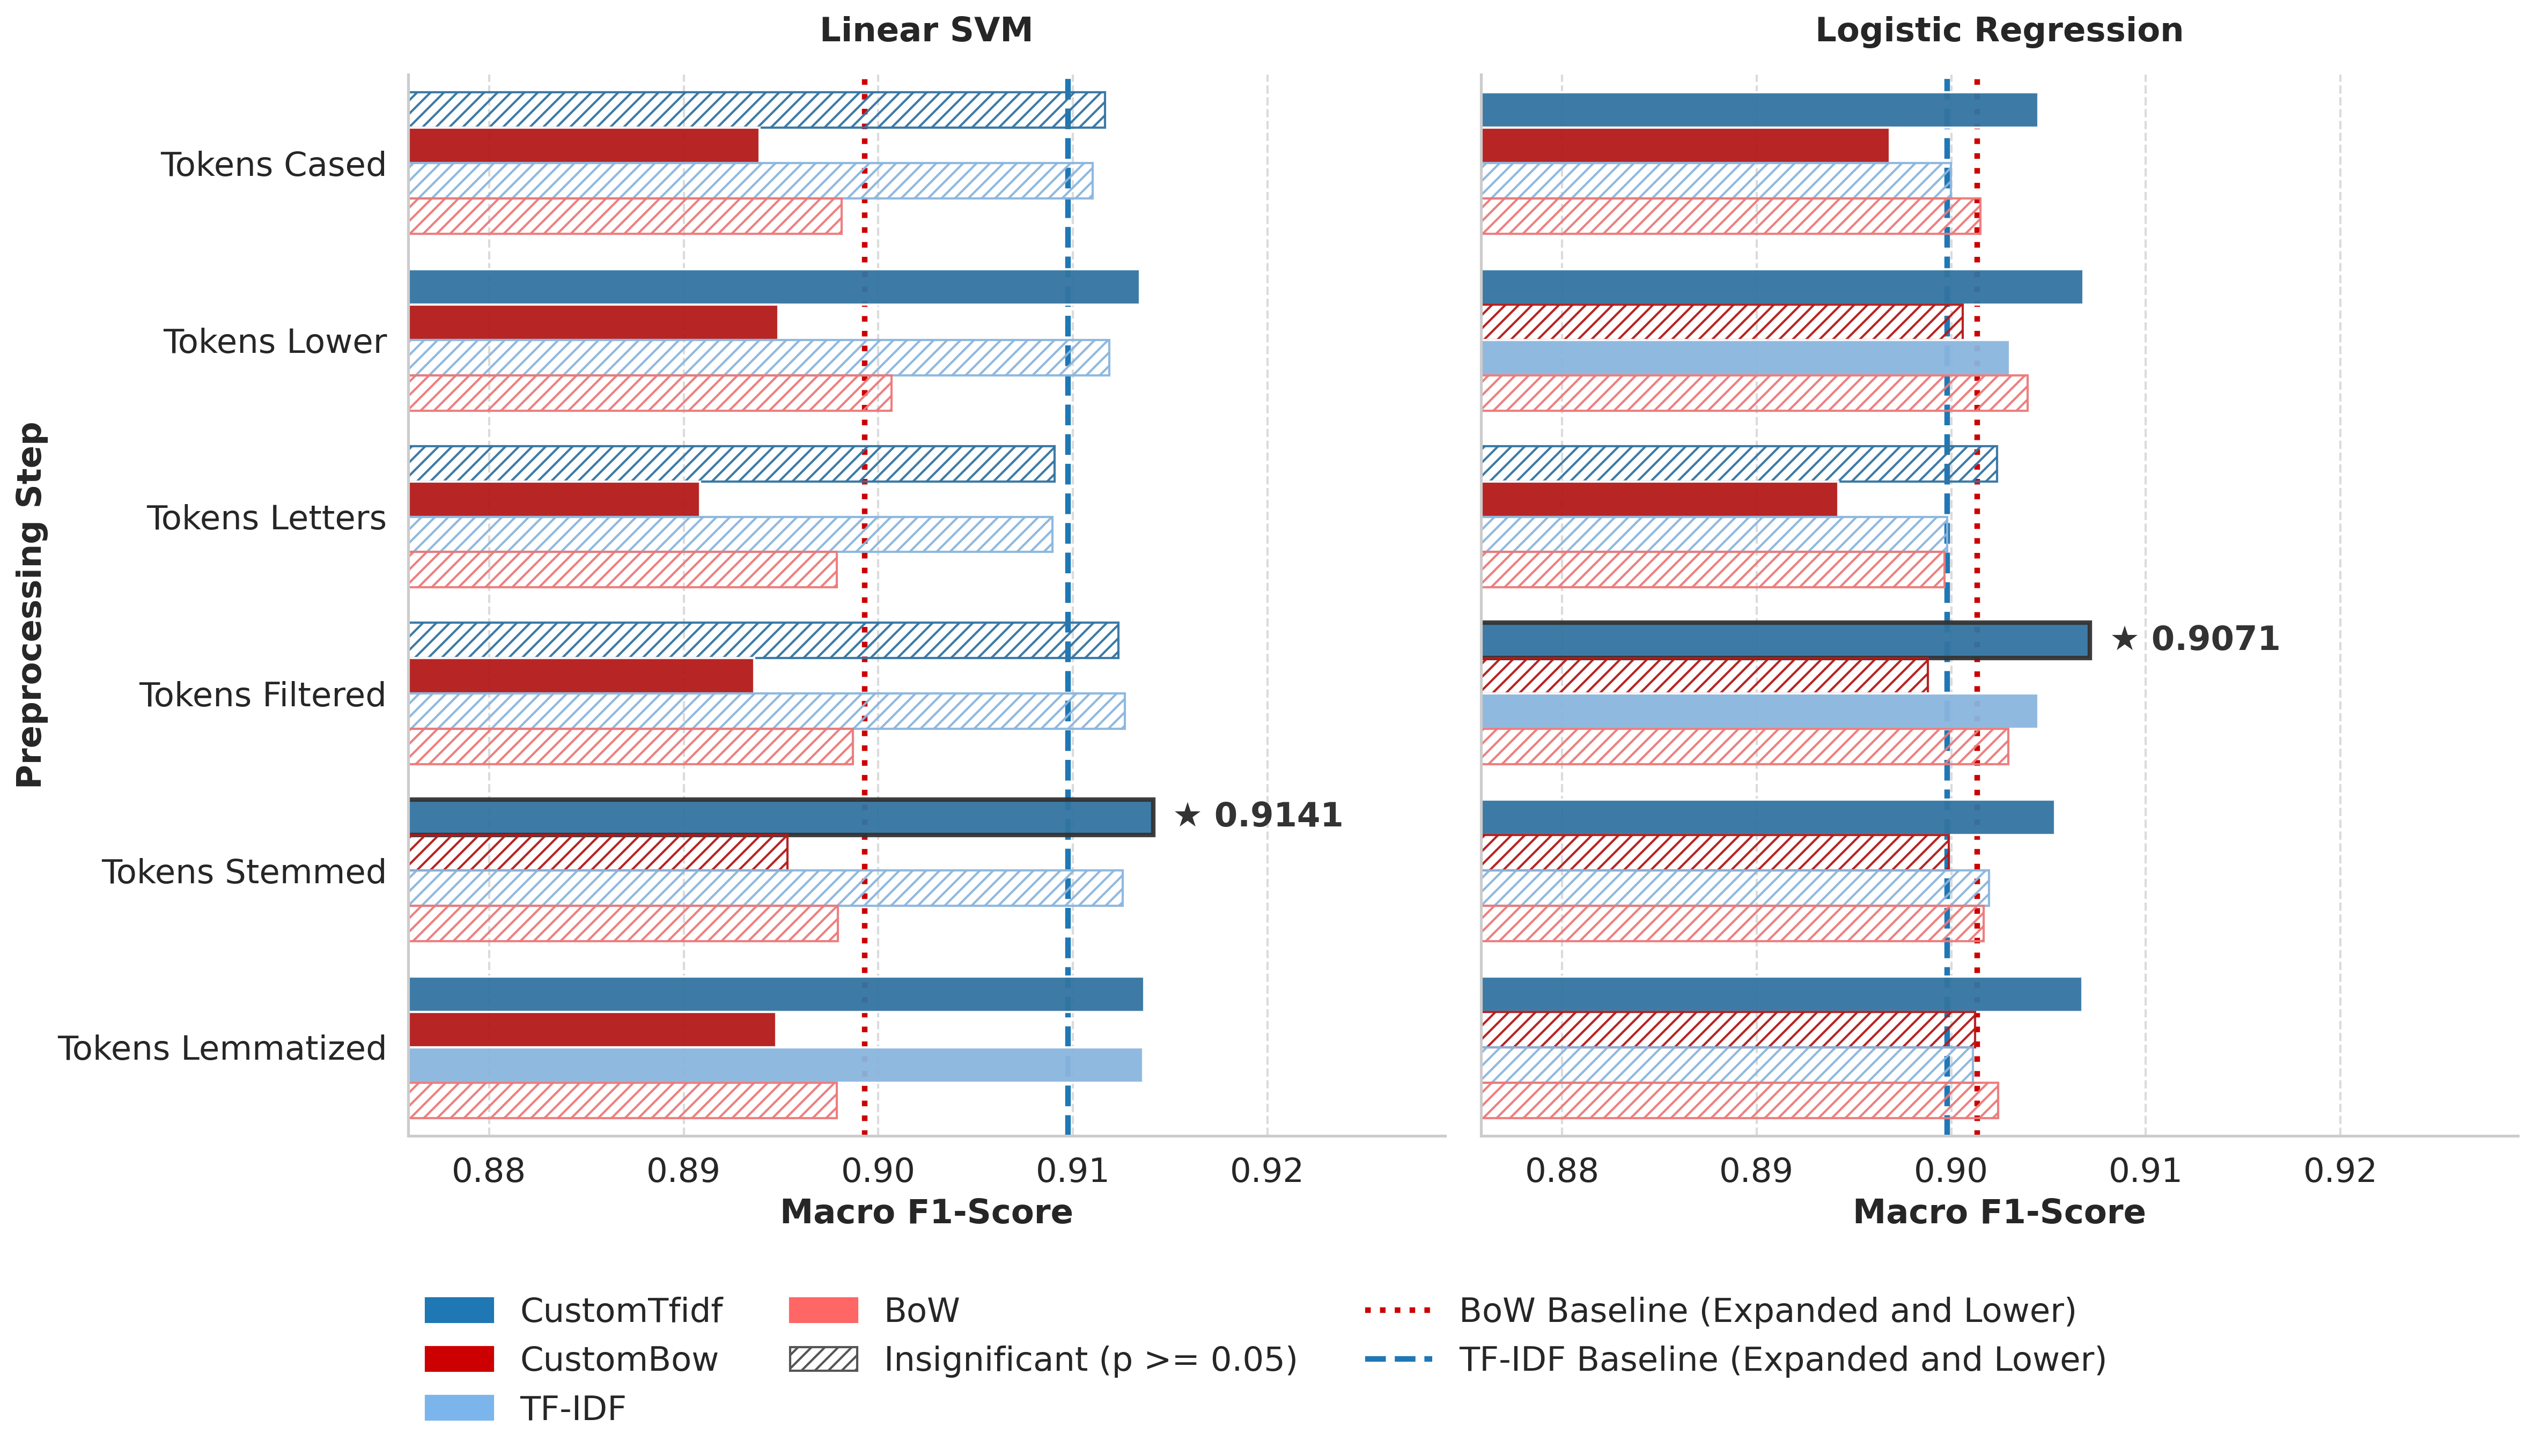

In [21]:
!python -m scripts.visualize_ablation_study --auto-run-mcnemar --force --z-threshold 2
display(Image("results/figures/analysis/ablation_study.png"))

In [57]:
!python -m scripts.run_n_grams

Loading data...
Testing N-Gram Ranges: 100%|██████████████████████████████████████████| 6/6 [00:47<00:00,  7.92s/it]


In [22]:
!python -m scripts.run_statistical_test \
    --targets "run_n_grams:::ng1-1_linear_svm=Lower | 1-1 N-Grams | Linear SVM" \
              "run_n_grams:::ng1-2_linear_svm=Lower | 1-2 N-Grams | Linear SVM" \
              "run_n_grams:::ng1-3_linear_svm=Lower | 1-3 N-Grams | Linear SVM" \
    --baseline val/run_custom/raw_predictions/tokens_lower_CustomTfidf_Z2_linear_svm.csv \
    --output n_gram_mcnemar_raport_1.csv

pokaz_wyniki_mcnemara(
    "results/analysis/n_gram_mcnemar_raport_1.csv", 
    p_threshold=0.05, 
    base_caption="McNemar Test (N-Grams vs Custom TF-IDF Z=2) - SVM", 
    representation="CustomTfidf (Z2)", 
    baseline_model_name="Linear SVM", 
    text="Lower"
)

/home/janek/Projekty/Sentiment/.venv/lib/python3.12/site-packages/statsmodels/stats/contingency_tables.py:1348: RuntimeWarning: divide by zero encountered in scalar divide
  statistic = (np.abs(n1 - n2) - corr)**2 / (1. * (n1 + n2))


/tmp/ipykernel_643/2448946076.py:30: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Baseline' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_results.loc[baseline_candidate.index[0], 'P_Value'] = 'Baseline'


,Text,Representation,Model,Acc_Model,Better,P_Value
0,Lower,1-3 N-Grams,Linear SVM,91.34%,,Baseline
1,Lower,1-1 N-Grams,Linear SVM,89.48%,↓,0.000000
2,Lower,1-2 N-Grams,Linear SVM,91.25%,,0.426614



--- Kod LaTeX ---
\begin{table}[htbp]
    \centering
\caption{McNemar Test (N-Grams vs Custom TF-IDF Z=2) - SVM}
\label{tab:McNemar}
\begin{tabular}{llllrcc}
\toprule
 & Text & Representation & Model & $Acc_{Model}$ & $\uparrow$/$\downarrow$ & $p$-value \\
\midrule
\textbf{0} & \textbf{Lower} & \textbf{1-3 N-Grams} & \textbf{Linear SVM} & \textbf{91.34\%} & \textbf{} & \textbf{Baseline} \\
\textbf{1} & \textbf{Lower} & \textbf{1-1 N-Grams} & \textbf{Linear SVM} & \textbf{89.48\%} & \textbf{$\downarrow$} & \textbf{0.000000} \\
2 & Lower & 1-2 N-Grams & Linear SVM & 91.25\% &  & 0.426614 \\
\bottomrule
\end{tabular}
\end{table}



In [23]:
!python -m scripts.run_statistical_test \
    --targets "run_n_grams:::ng1-1_logreg=Lower | 1-1 N-Grams | Logistic Regression" \
              "run_n_grams:::ng1-2_logreg=Lower | 1-2 N-Grams | Logistic Regression" \
              "run_n_grams:::ng1-3_logreg=Lower | 1-3 N-Grams | Logistic Regression" \
    --baseline val/run_custom/raw_predictions/tokens_lower_CustomTfidf_Z2_logreg.csv \
    --output n_gram_mcnemar_raport_2.csv

pokaz_wyniki_mcnemara(
    "results/analysis/n_gram_mcnemar_raport_2.csv", 
    p_threshold=0.05, 
    base_caption="McNemar Test (N-Grams vs Custom TF-IDF Z=2) - LogReg", 
    representation="CustomTfidf (Z2)", 
    baseline_model_name="Logistic Regression", 
    text="Lower"
)

/home/janek/Projekty/Sentiment/.venv/lib/python3.12/site-packages/statsmodels/stats/contingency_tables.py:1348: RuntimeWarning: divide by zero encountered in scalar divide
  statistic = (np.abs(n1 - n2) - corr)**2 / (1. * (n1 + n2))


/tmp/ipykernel_643/2448946076.py:30: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Baseline' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_results.loc[baseline_candidate.index[0], 'P_Value'] = 'Baseline'


,Text,Representation,Model,Acc_Model,Better,P_Value
0,Lower,1-3 N-Grams,Logistic Regression,90.68%,,Baseline
1,Lower,1-2 N-Grams,Logistic Regression,90.48%,↓,0.033933
2,Lower,1-1 N-Grams,Logistic Regression,89.02%,↓,0.000000



--- Kod LaTeX ---
\begin{table}[htbp]
    \centering
\caption{McNemar Test (N-Grams vs Custom TF-IDF Z=2) - LogReg}
\label{tab:McNemar}
\begin{tabular}{llllrcc}
\toprule
 & Text & Representation & Model & $Acc_{Model}$ & $\uparrow$/$\downarrow$ & $p$-value \\
\midrule
\textbf{0} & \textbf{Lower} & \textbf{1-3 N-Grams} & \textbf{Logistic Regression} & \textbf{90.68\%} & \textbf{} & \textbf{Baseline} \\
\textbf{1} & \textbf{Lower} & \textbf{1-2 N-Grams} & \textbf{Logistic Regression} & \textbf{90.48\%} & \textbf{$\downarrow$} & \textbf{0.033933} \\
\textbf{2} & \textbf{Lower} & \textbf{1-1 N-Grams} & \textbf{Logistic Regression} & \textbf{89.02\%} & \textbf{$\downarrow$} & \textbf{0.000000} \\
\bottomrule
\end{tabular}
\end{table}




--- Dimensionality of N-Gram Representations ---
N-Grams 1-1: Base Vocab = 18,471 features | Pruned (Z=2.0) = 6,668 features
N-Grams 1-2: Base Vocab = 85,132 features | Pruned (Z=2.0) = 23,841 features
N-Grams 1-3: Base Vocab = 139,015 features | Pruned (Z=2.0) = 36,350 features
------------------------------------------------

Saved double‑panel chart to: results/figures/analysis/ngram_experiment_double.png


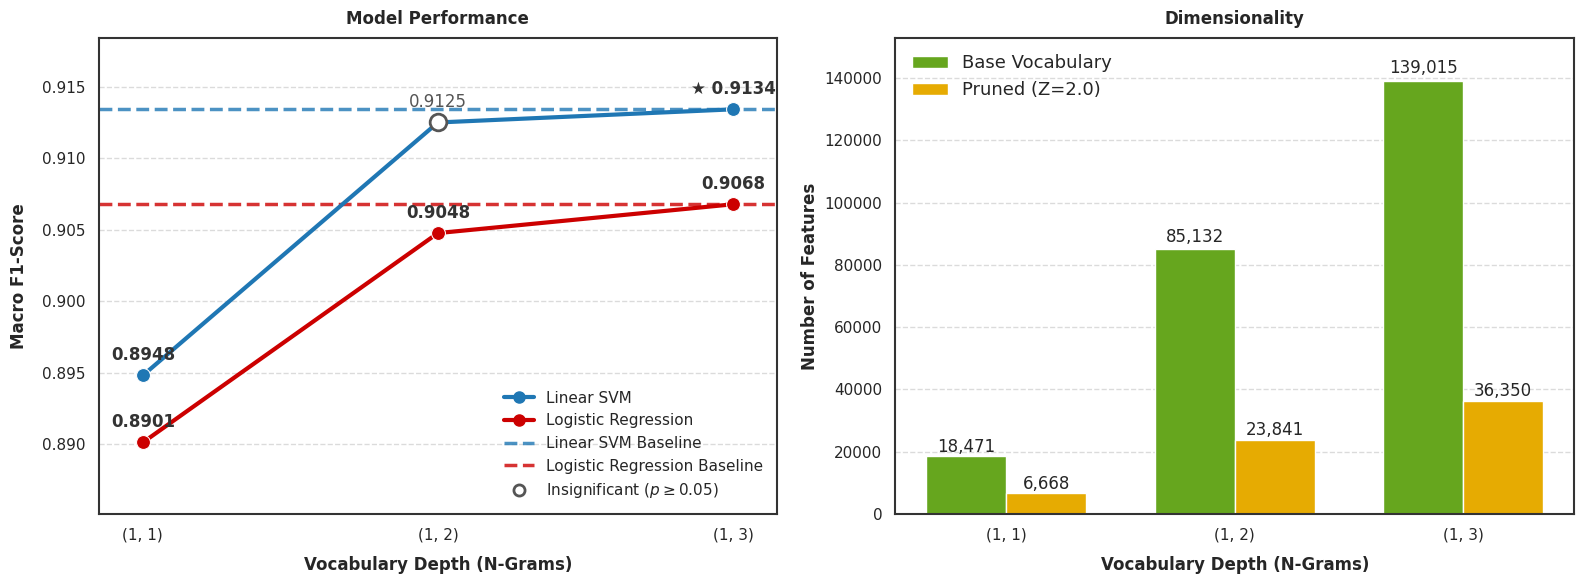

In [37]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from pathlib import Path

# Additional imports required to calculate dimensionality on the fly
from src.features.vectorizer import build_count_matrix
from src.features.sentiment import SentimentFeatures

def plot_ngram_results_polished(
    reports_dir="results/val/run_n_grams/classification_reports",
    mcnemar_csv_paths=[
        "results/analysis/n_gram_mcnemar_raport_1.csv", 
        "results/analysis/n_gram_mcnemar_raport_2.csv"
    ],
    baseline_dir="results/val/run_custom/classification_reports",
    baseline_prefix="tokens_lower_CustomTfidf_Z2"
):
    reports_path = Path(reports_dir)
    ngram_ranges = ["1-1", "1-2", "1-3"]
    models = {"linear_svm": "Linear SVM", "logreg": "Logistic Regression"}
    z_threshold = 2.0

    # =========================================================================
    # 0. Calculate Dimensionalities and store them for plotting
    # =========================================================================
    dim_dict = {}   # key: ngram_range string, value: (base_dim, pruned_dim)
    print("\n--- Dimensionality of N-Gram Representations ---")
    try:
        train_df = pd.read_parquet("data/preprocessed/train.parquet")
        y_train = train_df["sentiment"].values
        
        for ng_str in ngram_ranges:
            ngram_tuple = tuple(map(int, ng_str.split('-')))
            
            # Build base matrix to get initial vocab size (val_tokens=None to save time)
            X_train, _, _ = build_count_matrix(
                train_df['tokens_lower'], None, ngram_range=ngram_tuple
            )
            base_dim = X_train.shape[1]
            
            # Apply Z-score to get pruned size
            sf = SentimentFeatures()
            sf.fit(X_train, y_train.tolist())
            pruned_dim = len(sf.filter_by_zscore(z_threshold))
            
            dim_dict[ng_str] = (base_dim, pruned_dim)
            print(f"N-Grams {ng_str}: Base Vocab = {base_dim:,} features | Pruned (Z={z_threshold}) = {pruned_dim:,} features")
    except Exception as e:
        print(f"Could not calculate dimensionalities: {e}")
    print("-" * 48 + "\n")

    # =========================================================================
    # 1. Load McNemar P-values with (Target, Baseline) pairs
    # =========================================================================
    p_values = {}
    for mcnemar_csv_path in mcnemar_csv_paths:
        mcnemar_path = Path(mcnemar_csv_path)
        if mcnemar_path.exists():
            df_mc = pd.read_csv(mcnemar_path)
            for _, row in df_mc.iterrows():
                rep = str(row.get('Representation', '')).strip()
                model = str(row.get('Model', '')).strip()

                if "1-1" in rep: ng = "1-1"
                elif "1-2" in rep: ng = "1-2"
                elif "1-3" in rep: ng = "1-3"
                else: ng = None

                if "SVM" in model: m_key = "linear_svm"
                elif "Log" in model: m_key = "logreg"
                else: m_key = None

                if ng and m_key:
                    comp_name = f"ng{ng}_{m_key}"
                else:
                    comp_col = 'Compared_Model' if 'Compared_Model' in df_mc.columns else 'Model'
                    comp_name = row[comp_col]
                    if ":::" in comp_name: comp_name = comp_name.split(":::")[-1]
                    elif "/" in comp_name or "\\" in comp_name: comp_name = Path(comp_name).stem
                
                base_name = row['Baseline']
                if ":::" in base_name: base_name = base_name.split(":::")[-1]
                elif "/" in base_name or "\\" in base_name: base_name = Path(base_name).stem
                
                p_values[(comp_name, base_name)] = row['P_Value']
        else:
            print(f"Warning: McNemar report not found at {mcnemar_path}.")

    # =========================================================================
    # 2. Load Baseline F1-scores & N-Gram data
    # =========================================================================
    baselines = {}
    b_dir_path = Path(baseline_dir)
    for m_key, m_label in models.items():
        b_path = b_dir_path / f"{baseline_prefix}_{m_key}.csv"
        if b_path.exists():
            df_base = pd.read_csv(b_path, index_col=0)
            baselines[m_label] = df_base.loc["macro avg", "f1-score"]
        else:
            print(f"Warning: Baseline report not found for {m_label} at {b_path}.")

    records = []
    for ng in ngram_ranges:
        for m_key, m_label in models.items():
            filename = f"ng{ng}_{m_key}.csv"
            filepath = reports_path / filename

            if filepath.exists():
                df = pd.read_csv(filepath, index_col=0)
                
                stem = filepath.stem
                expected_baseline_stem = f"{baseline_prefix}_{m_key}"
                
                if (stem, expected_baseline_stem) in p_values:
                    p_val = p_values[(stem, expected_baseline_stem)]
                    is_sig = p_val < 0.05
                else:
                    is_sig = True 
                
                records.append({
                    "N-Gram Range": f"({ng.replace('-', ', ')})", 
                    "Model": m_label,
                    "Macro F1-Score": df.loc["macro avg", "f1-score"],
                    "Filename": stem,
                    "Is Significant": is_sig
                })

    if not records:
        print("No matching files found!")
        return

    results_df = pd.DataFrame(records)

    # =========================================================================
    # 3. Canvas Setup – two subplots side by side
    # =========================================================================
    FONT_SIZE = 15
    plt.rcParams.update({
        'font.size': FONT_SIZE,
        'axes.labelsize': FONT_SIZE,
        'xtick.labelsize': FONT_SIZE,
        'ytick.labelsize': FONT_SIZE,
        'legend.fontsize': FONT_SIZE,
        'legend.title_fontsize': FONT_SIZE,
    })
    
    sns.set_theme(style="whitegrid")
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # =========================================================================
    # 3a. Left subplot – F1 line chart (Vocabulary Depth)
    # =========================================================================
    custom_palette = {"Linear SVM": "#1F77B4", "Logistic Regression": "#CC0000"}
    insig_edge = "#555555"

    sns.lineplot(
        data=results_df, 
        x="N-Gram Range", 
        y="Macro F1-Score", 
        hue="Model",
        palette=custom_palette,
        marker='o',
        markersize=10,
        linewidth=3,
        ax=ax1,
        zorder=3
    )

    for m_label, b_f1 in baselines.items():
        color = custom_palette[m_label]
        ax1.axhline(y=b_f1, color=color, linestyle='--', linewidth=2.5, alpha=0.8, zorder=1)

    for i, row in results_df.iterrows():
        is_best = (row['Macro F1-Score'] == results_df['Macro F1-Score'].max())
        prefix = "★ " if is_best else ""
        
        is_sig = row["Is Significant"]
        if not is_sig:
            ax1.plot(
                row["N-Gram Range"], 
                row["Macro F1-Score"], 
                marker='o',
                markersize=12,
                markerfacecolor='white',
                markeredgecolor=insig_edge,
                markeredgewidth=2,
                linestyle='None',
                zorder=4
            )

        text_color = '#333333' if is_sig else insig_edge
        font_weight = 'bold' if is_sig else 'normal'
        ax1.text(
            x=row["N-Gram Range"],
            y=row["Macro F1-Score"] + 0.0008,
            s=f"{prefix}{row['Macro F1-Score']:.4f}",
            color=text_color,
            fontweight=font_weight,
            ha='center',
            va='bottom'
        )

    ax1.set_ylabel("Macro F1-Score", fontweight='bold', labelpad=10)
    ax1.set_title("Model Performance", fontweight='bold', pad=10)
    ax1.set_xlabel("Vocabulary Depth (N-Grams)", fontweight='bold', labelpad=10)
    ax1.set_xlim(-0.15, 2.15)

    y_vals = results_df["Macro F1-Score"].tolist() + list(baselines.values())
    if y_vals:
        y_min = min(y_vals) - 0.005
        y_max = max(y_vals) + 0.005
        ax1.set_ylim(y_min, y_max)

    ax1.grid(axis='y', linestyle='--', alpha=0.7)
    ax1.grid(axis='x', visible=False)

    for spine in ax1.spines.values():
        spine.set_visible(True)
        spine.set_color('#333333')
        spine.set_linewidth(1.5)

    ax1.legend_.remove()
    custom_handles = []
    for m_label in results_df['Model'].unique():
        custom_handles.append(mlines.Line2D([], [], color=custom_palette[m_label], marker='o', markersize=8, label=m_label, linewidth=3))
    for m_label, b_f1 in baselines.items():
        color = custom_palette[m_label]
        custom_handles.append(mlines.Line2D([], [], color=color, linestyle='--', linewidth=2.5, alpha=0.8, label=f'{m_label} Baseline'))
    if not results_df["Is Significant"].all():
        custom_handles.append(mlines.Line2D([], [], color='white', marker='o', markeredgecolor=insig_edge, markeredgewidth=2, markersize=8, label='Insignificant ($p \geq 0.05$)'))
    ax1.legend(handles=custom_handles, loc='lower right', frameon=False)

    # =========================================================================
    # 3b. Right subplot – Dimensionality bar chart 
    # =========================================================================
    if dim_dict:
        ng_labels = ["(1, 1)", "(1, 2)", "(1, 3)"]   
        ng_keys   = ["1-1", "1-2", "1-3"]            

        base_vals = [dim_dict[ng][0] for ng in ng_keys]
        pruned_vals = [dim_dict[ng][1] for ng in ng_keys]
        x = range(len(ng_labels))
        width = 0.35

        bars_base = ax2.bar([i - width/2 for i in x], base_vals, width, 
                            color='#66A61E', label='Base Vocabulary')
        bars_pruned = ax2.bar([i + width/2 for i in x], pruned_vals, width,
                              color='#E6AB02', label=f'Pruned (Z={z_threshold})')
        
        ax2.set_xticks(x)
        ax2.set_xticklabels(ng_labels)
        ax2.set_xlabel("Vocabulary Depth (N-Grams)", fontweight='bold', labelpad=10)
        ax2.set_ylabel("Number of Features", fontweight='bold')
        ax2.set_title("Dimensionality", fontweight='bold', pad=10)

        for bar in bars_base:
            height = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width()/2., height + height*0.01,
                     f'{height:,}', ha='center', va='bottom', fontsize=12)
        for bar in bars_pruned:
            height = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width()/2., height + height*0.01,
                     f'{height:,}', ha='center', va='bottom', fontsize=12)

        all_vals = base_vals + pruned_vals
        ax2.set_ylim(0, max(all_vals) * 1.1)

        ax2.grid(axis='y', linestyle='--', alpha=0.7)
        ax2.grid(axis='x', visible=False)
        for spine in ax2.spines.values():
            spine.set_visible(True)
            spine.set_color('#333333')
            spine.set_linewidth(1.5)
        ax2.legend(frameon=False, fontsize=13)
    else:
        ax2.text(0.5, 0.5, "Dimensionality data unavailable", 
                 ha='center', va='center', transform=ax2.transAxes,
                 fontsize=14)
        ax2.set_title("Dimensionality", fontweight='bold')

    plt.tight_layout()

    out_dir = Path("results/figures/analysis")
    out_dir.mkdir(parents=True, exist_ok=True)
    out_path = out_dir / "ngram_experiment_double.png"
    plt.savefig(out_path, dpi=300, bbox_inches='tight')
    print(f"Saved double‑panel chart to: {out_path}")
    plt.show()

if __name__ == "__main__":
    plot_ngram_results_polished()

Tri-grams have higher performance than uni-grams.

There is no significant difference between (1-2)- and (1-3)grams.

In [1]:
!python -m scripts.run_svms

Loading data...
---> Training linear_svm took: 1.90 seconds                                                         
Testing svm kernels:  50%|██████████████████████                      | 1/2 [00:25<00:25, 25.99s/it]WARN: libsvm Solver reached max_iter
optimization finished, #iter = 1000
obj = -1332.301121, rho = -0.013982
nSV = 2000, nBSV = 2000
Total nSV = 2000
/home/janek/Projekty/Sentiment/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
WARN: libsvm Solver reached max_iter
optimization finished, #iter = 1000
obj = -1331.779165, rho = -0.000823
nSV = 2000, nBSV = 2000
Total nSV = 2000
/home/janek/Projekty/Sentiment/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(

In [29]:
!python -m scripts.run_statistical_test \
    --targets \
              "run_svms::ng1-3_rbf_svm_1000:=Lower | 267.07 | RBF SVM (1,000)" \
              "run_svms::ng1-3_rbf_svm_10000:=Lower | 2042.05 | RBF SVM (10,000)" \
    --baseline val/run_svms/raw_predictions/ng1-3_linear_svm_10000.csv \
    --output svms_mcnemar_raport.csv

pokaz_wyniki_mcnemara(
    "results/analysis/svms_mcnemar_raport.csv", 
    p_threshold=0.05,
    base_caption="McNemar Test linear SVM vs Rfb SVM", 
    representation="1.89", 
    baseline_model_name="Linear SVM (10,000)", 
    text="Lower"
)

,Text,Representation,Model,Acc_Model,Better,P_Value
0,Lower,1.89,"Linear SVM (10,000)",91.34%,,Baseline
1,Lower,267.070000,"RBF SVM (1,000)",89.03%,↓,0.000000
2,Lower,2042.050000,"RBF SVM (10,000)",91.15%,,0.142368



--- Kod LaTeX ---
\begin{table}[htbp]
    \centering
\caption{McNemar Test linear SVM vs Rfb SVM}
\label{tab:McNemar}
\begin{tabular}{llllrcc}
\toprule
 & Text & Representation & Model & $Acc_{Model}$ & $\uparrow$/$\downarrow$ & $p$-value \\
\midrule
\textbf{0} & \textbf{Lower} & \textbf{1.89} & \textbf{Linear SVM (10,000)} & \textbf{91.34\%} & \textbf{} & \textbf{Baseline} \\
\textbf{1} & \textbf{Lower} & \textbf{267.07} & \textbf{RBF SVM (1,000)} & \textbf{89.03\%} & \textbf{$\downarrow$} & \textbf{0.000000} \\
2 & Lower & 2042.050000 & RBF SVM (10,000) & 91.15\% &  & 0.142368 \\
\bottomrule
\end{tabular}
\end{table}



In [26]:
ls -l results/val/run_svms/raw_predictions/

total 1108
-rw-r--r-- 1 janek janek 377171 May 18 17:32 ng1-3_linear_svm_10000.csv
-rw-r--r-- 1 janek janek 371040 May 19 09:57 ng1-3_rbf_svm_1000.csv
-rw-r--r-- 1 janek janek 377117 May 18 18:47 ng1-3_rbf_svm_10000.csv


# CONCEPTS

In [66]:
config_path = "configs/default.yaml"

with open(config_path) as f:
    base_cfg = yaml.safe_load(f)

print(f"Keys: {base_cfg}")

Keys: {'bert': {'sentence_model': 'all-MiniLM-L6-v2', 'basic': {'model_name': 'distilbert-base-uncased-finetuned-sst-2-english', 'epochs': 3, 'batch_size': 16, 'max_len': 256, 'learning_rate': '2e-5', 'patience': 2}, 'specialist': {'epochs': 3, 'batch_size': 8, 'learning_rate': '1e-5', 'num_layers_to_freeze': 4, 'patience': 8}}, 'grid_search': {'models': ['linear_svm', 'logreg'], 'n_concepts': [0, 500, 5000, 10000], 'sentiment_weight': [0.0, 1.0, 10.0]}}


In [69]:
# 2. Build Feature Factory
!python -m scripts.build_features --config configs/default.yaml

2026-03-12 16:45:29.833324: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/janek/Projekty/Sentiment/.venv/lib/python3.12/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):
=== PHASE 1: Build unit matrices ===
Building unit matrices for 'tokens_lower' ...
Unit matrices for 'tokens_lower' saved.

=== PHASE 2: Compute unit Z‑score indices ===
   Unit Z=2.0: kept 36350 features.

=== PHASE 3: Compute embeddings (needed for concepts) ===
Embeddings for 'tokens_lower' saved.

=== PHASE 4: Extract concepts for each (k, w) combination ===
Concepts for 'tokens_lower' k=500 w=0.0 saved.
Concepts for 'tokens_lower' k=500 w=1.0 saved.
Conc


=== Processing weight = 0.0 ===
Loaded 139015 units mapped to 10000 concepts.
Saved compact lollipop plot to /home/janek/Projekty/Sentiment/results/figures/concepts/lollipop_tokens_lower_k10000_w0.png
Saved word cloud grid to /home/janek/Projekty/Sentiment/results/figures/concepts/pos_wc_tokens_lower_k10000_w0.png
Saved word cloud grid to /home/janek/Projekty/Sentiment/results/figures/concepts/neg_wc_tokens_lower_k10000_w0.png

=== Processing weight = 10.0 ===
Loaded 139015 units mapped to 10000 concepts.
Saved compact lollipop plot to /home/janek/Projekty/Sentiment/results/figures/concepts/lollipop_tokens_lower_k10000_w10.png
Saved word cloud grid to /home/janek/Projekty/Sentiment/results/figures/concepts/pos_wc_tokens_lower_k10000_w10.png
Saved word cloud grid to /home/janek/Projekty/Sentiment/results/figures/concepts/neg_wc_tokens_lower_k10000_w10.png


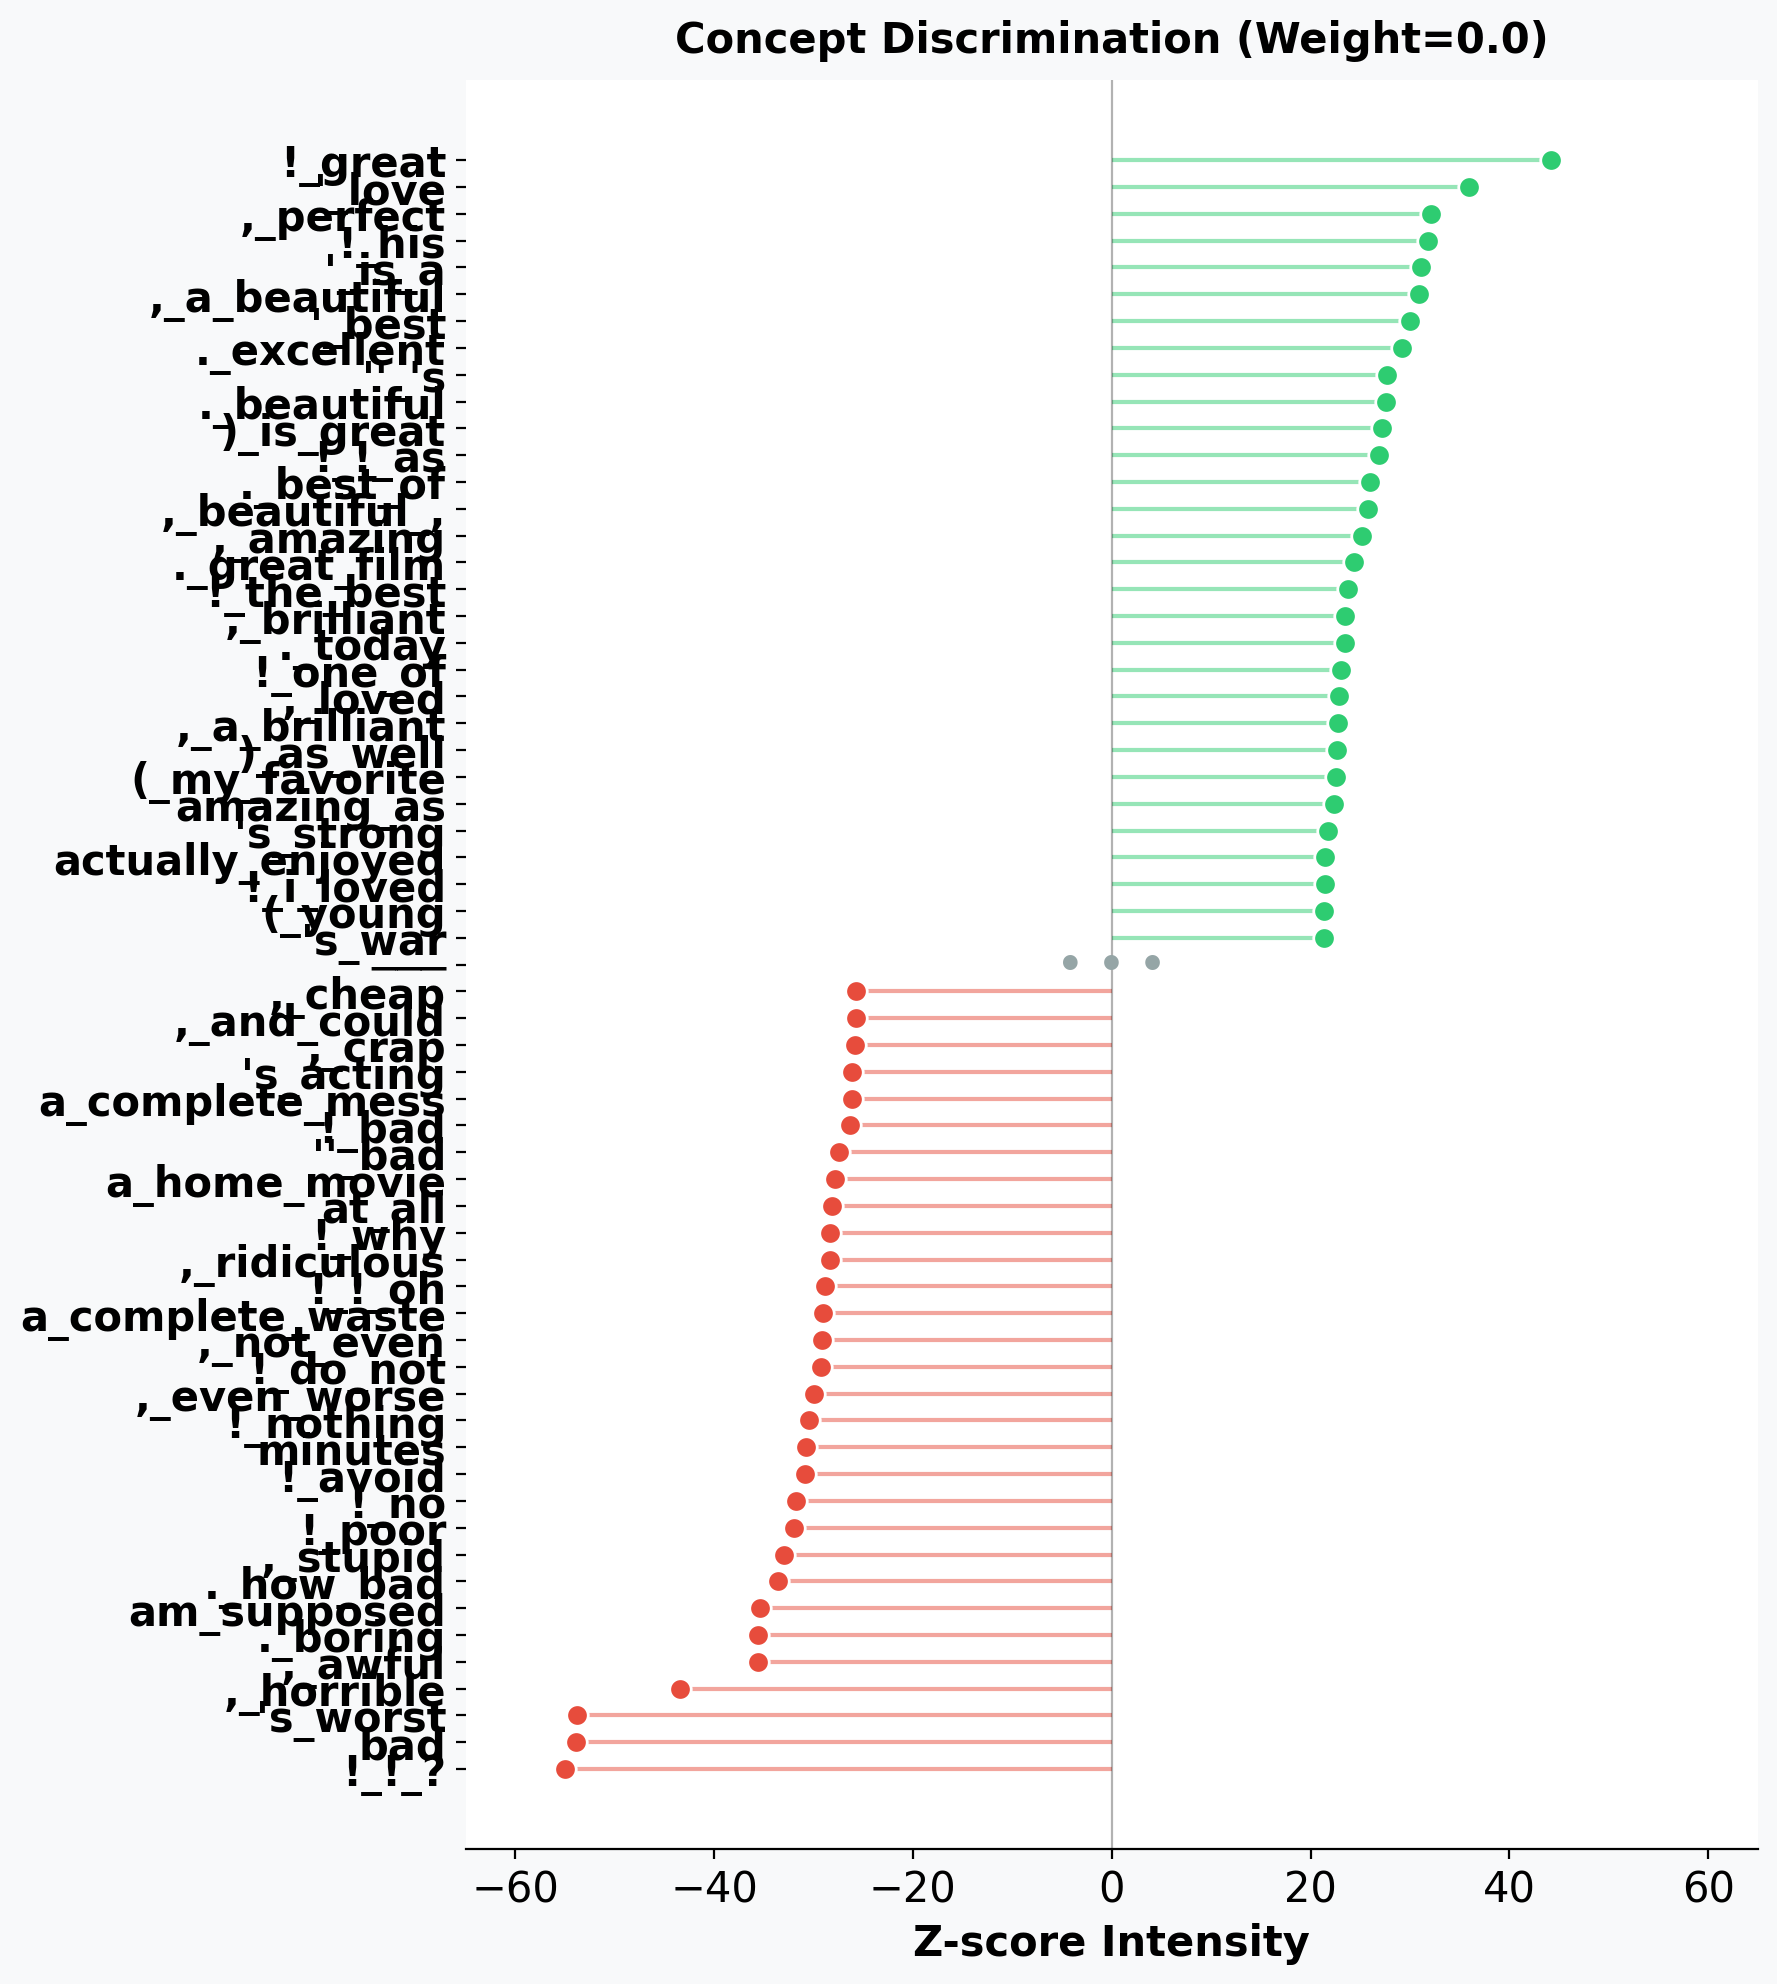

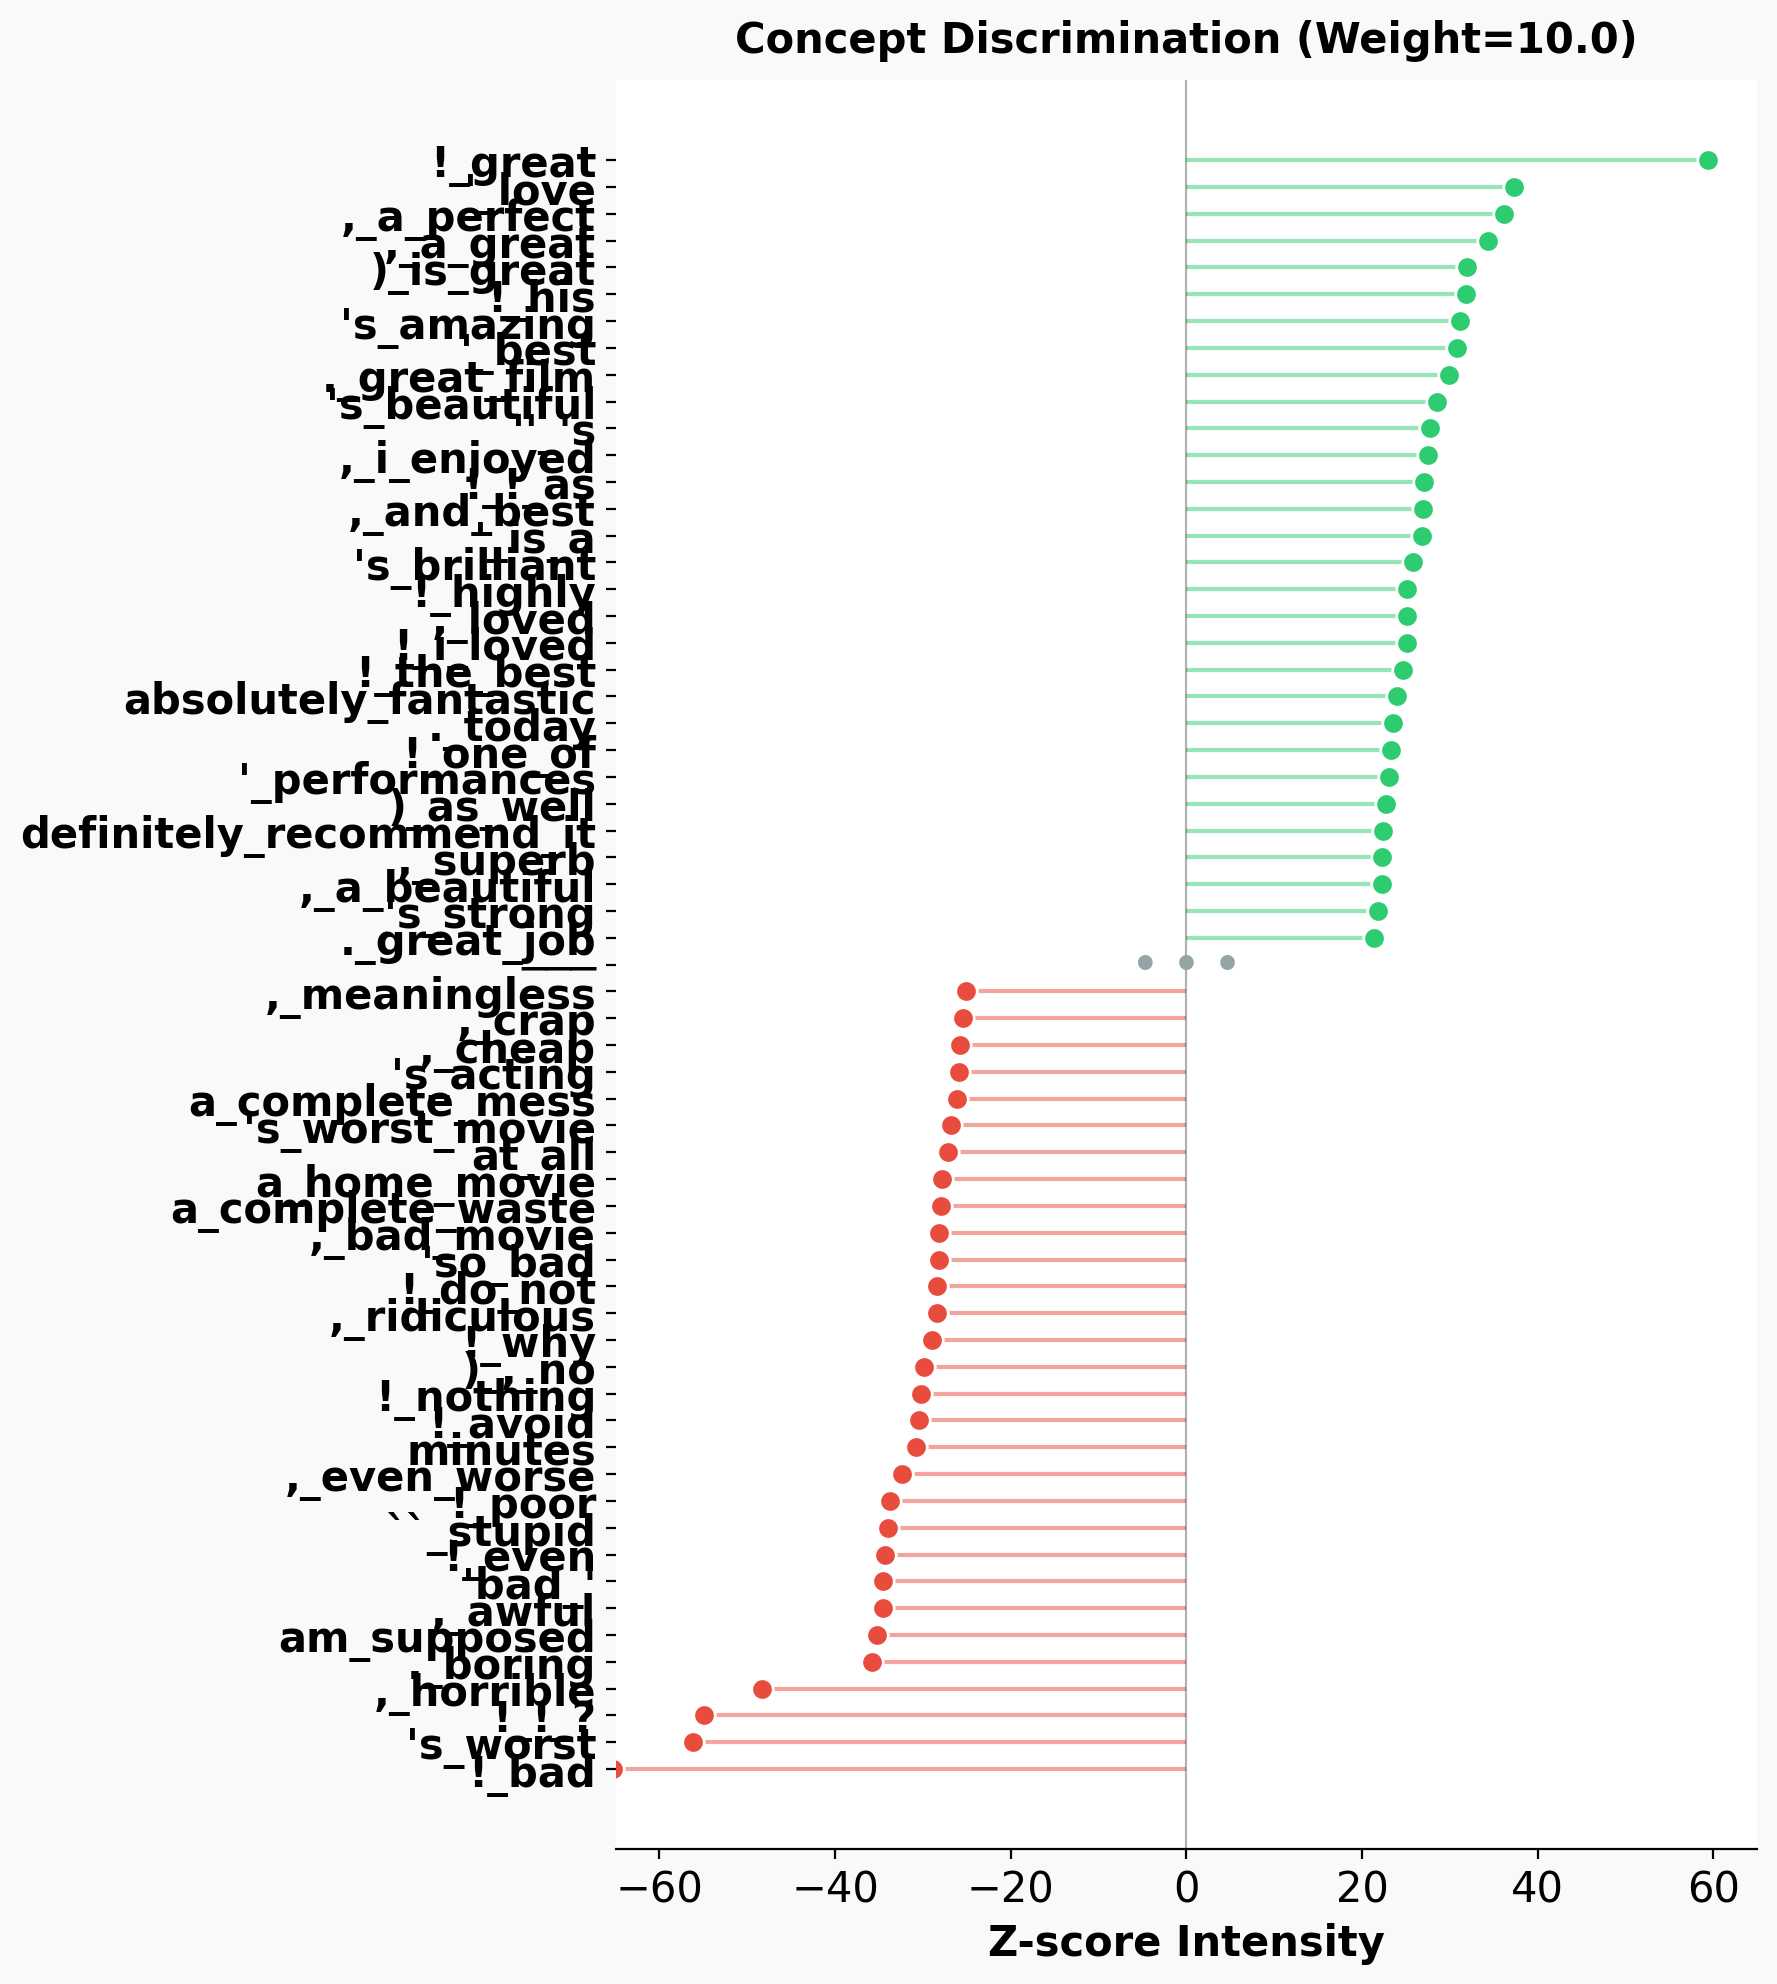

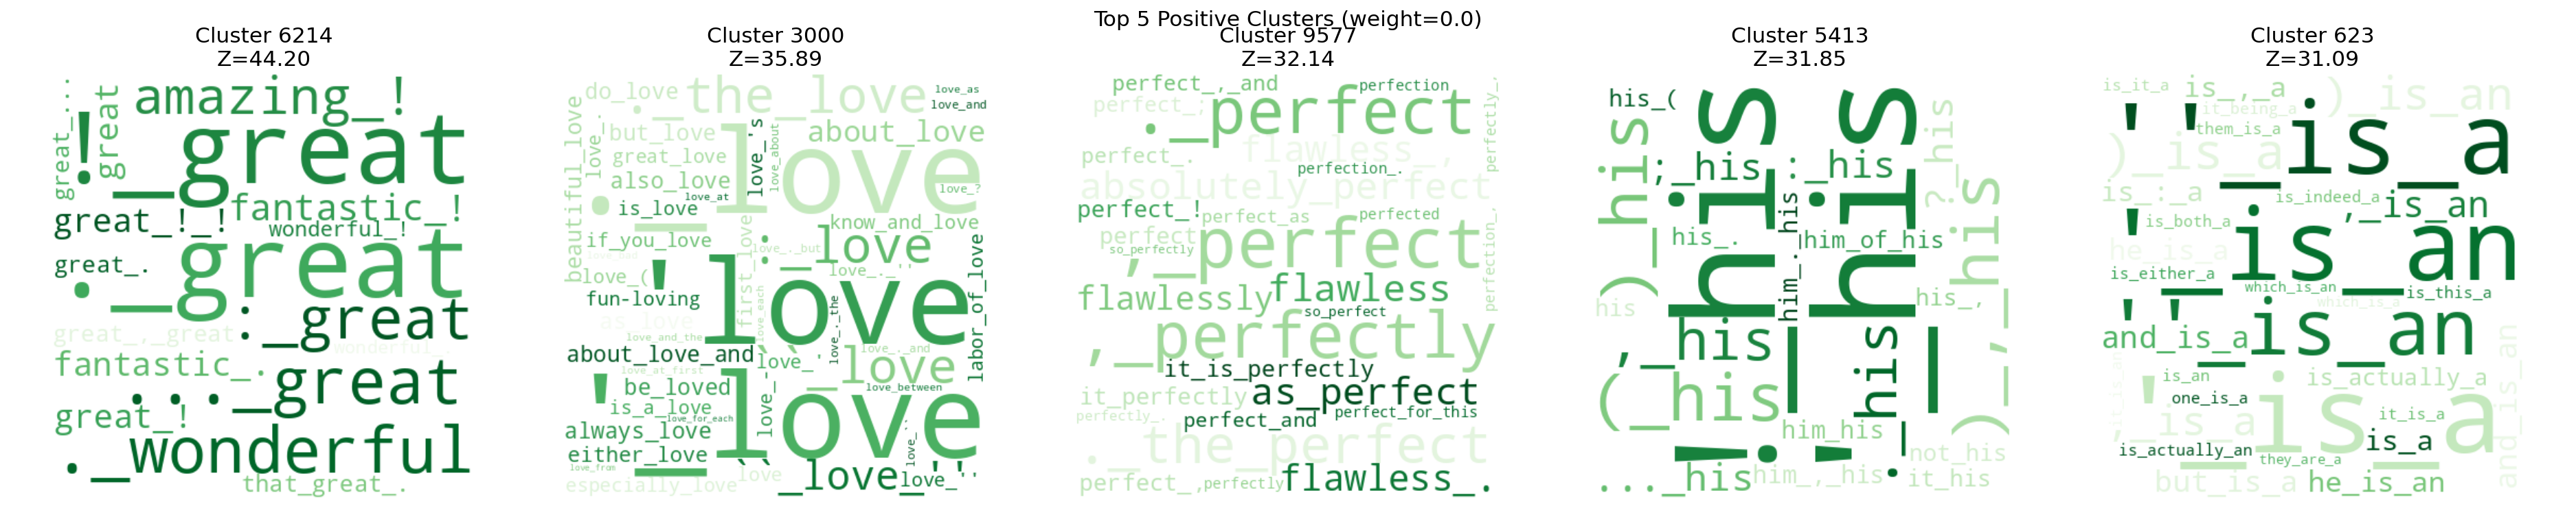

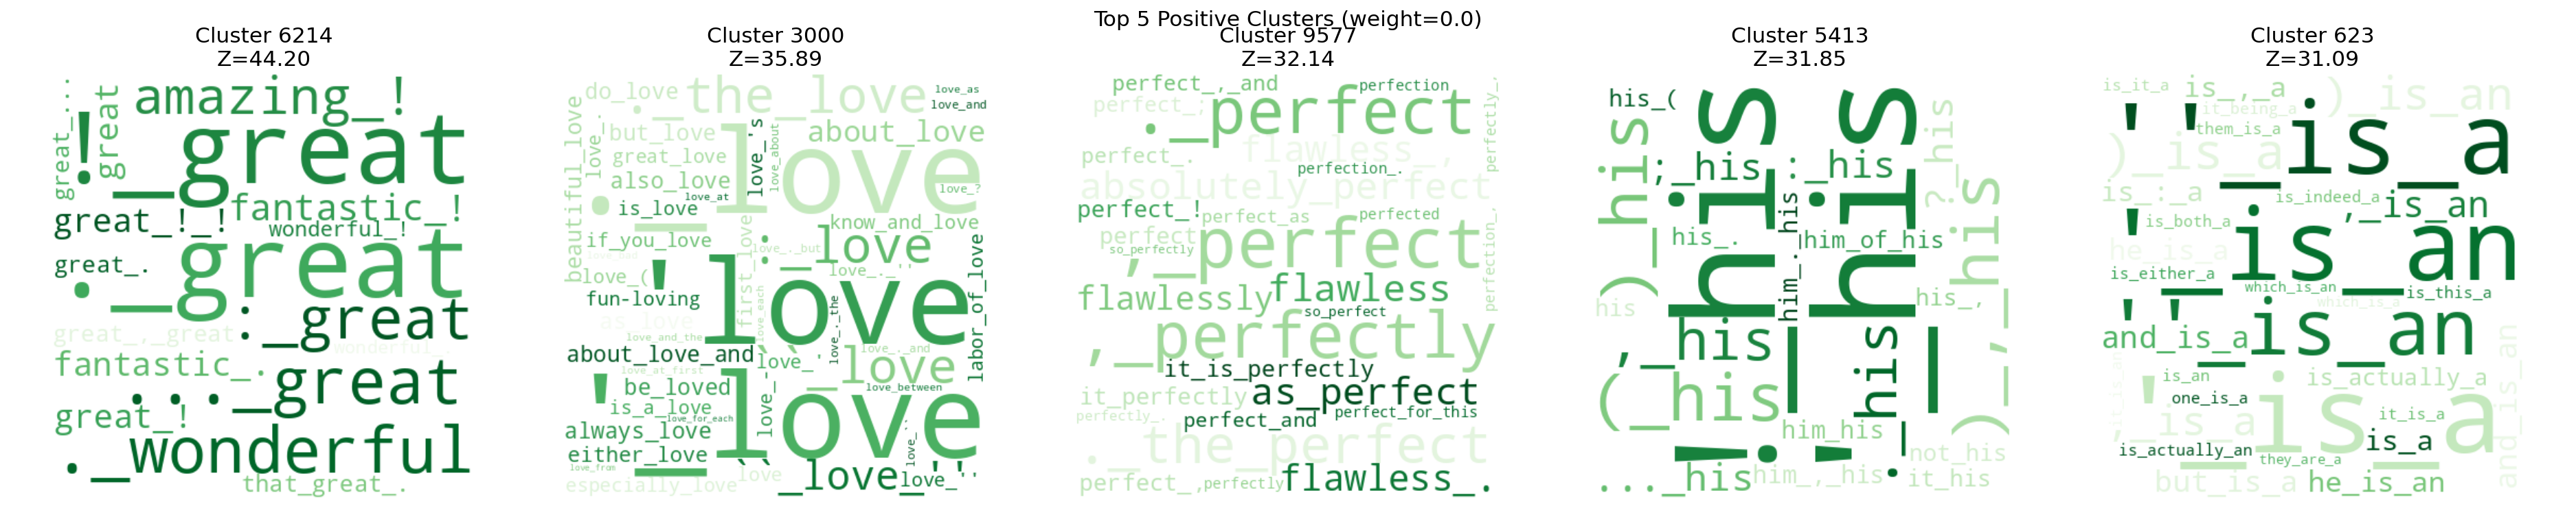

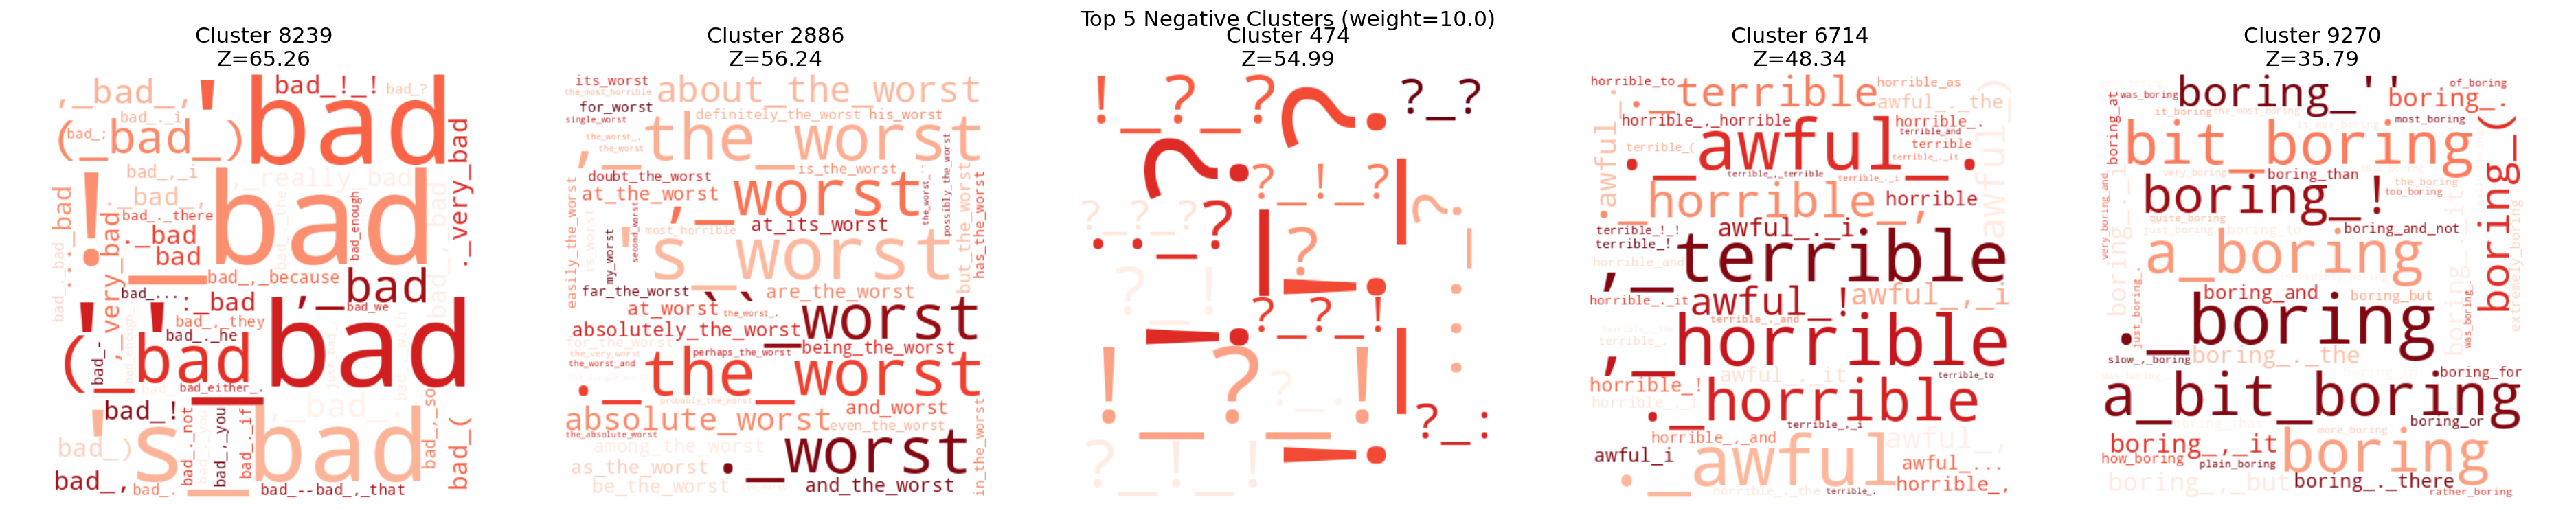

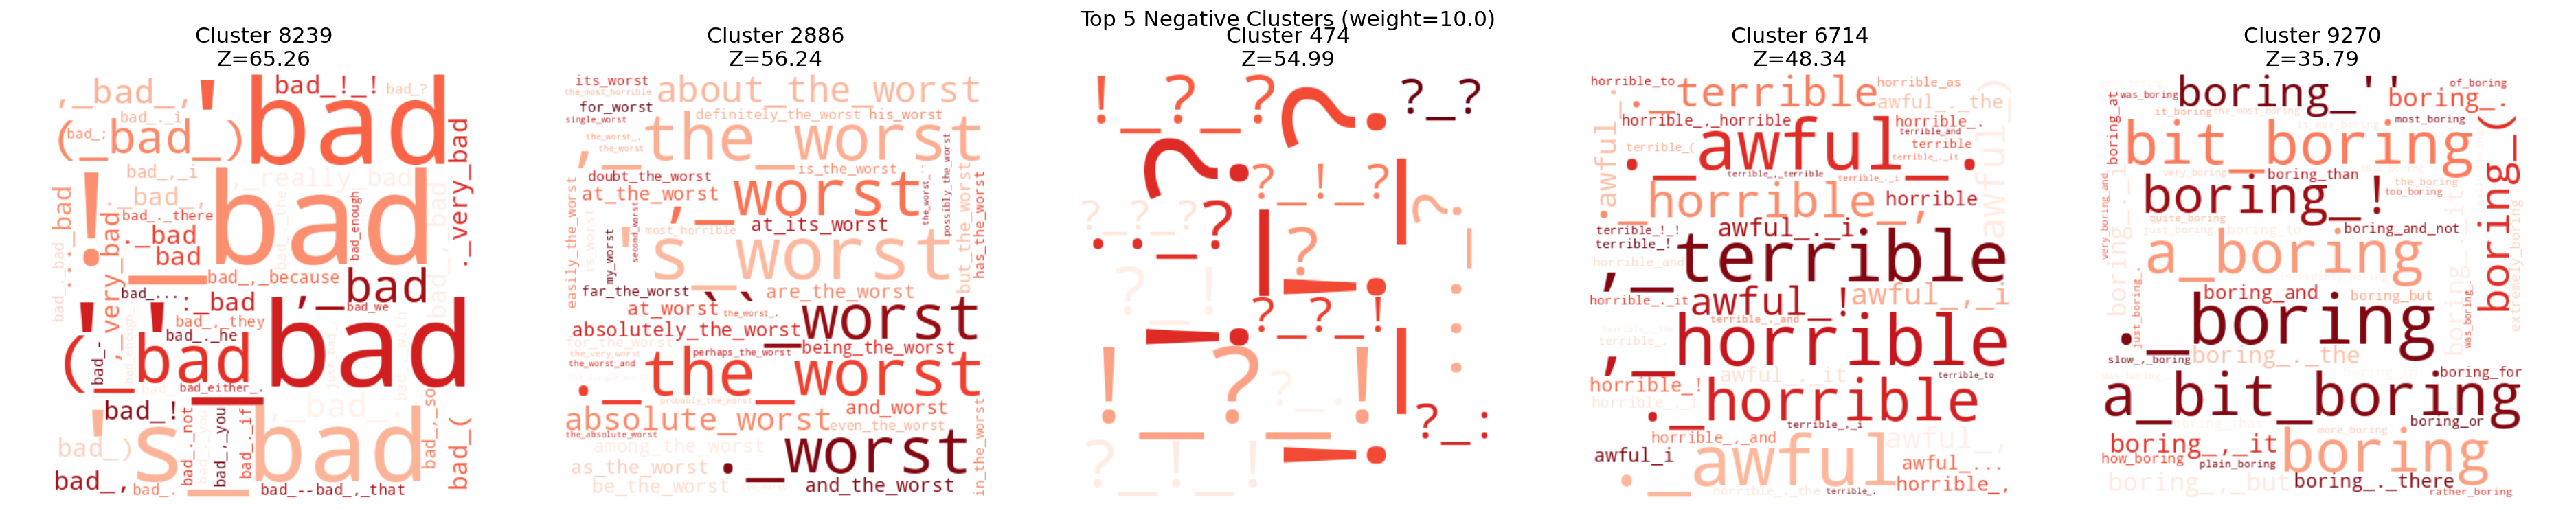

In [3]:
!python -m scripts.visualize_concepts --token_col tokens_lower --n_concepts 10000 --weights 0 10 --top_n 30
display(Image("results/figures/concepts/lollipop_tokens_lower_k10000_w0.png"))
display(Image("results/figures/concepts/lollipop_tokens_lower_k10000_w10.png"))
display(Image("results/figures/concepts/pos_wc_tokens_lower_k10000_w0.png"))
display(Image("results/figures/concepts/pos_wc_tokens_lower_k10000_w0.png"))
display(Image("results/figures/concepts/neg_wc_tokens_lower_k10000_w10.png"))
display(Image("results/figures/concepts/neg_wc_tokens_lower_k10000_w10.png"))

In [72]:
!python -m scripts.grid_search --config configs/default.yaml --workers 1

2026-03-12 17:10:53.871160: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/janek/Projekty/Sentiment/.venv/lib/python3.12/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):
2026-03-12 17:11:00.769323: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Dask Dashboard available at: http://127.0.0.1:8787/status
Starting Grid Search with 20 iterations...
Grid Search Progress: 100%|█████████████████████| 

In [10]:
!python -m scripts.visualize_cluster_comparison
from IPython.display import IFrame
display(IFrame("results/figures/analysis/cluster_comparison.pdf", width=1000, height=400))

Saved aesthetically improved plot to results/figures/analysis/cluster_comparison.pdf


# Certainty

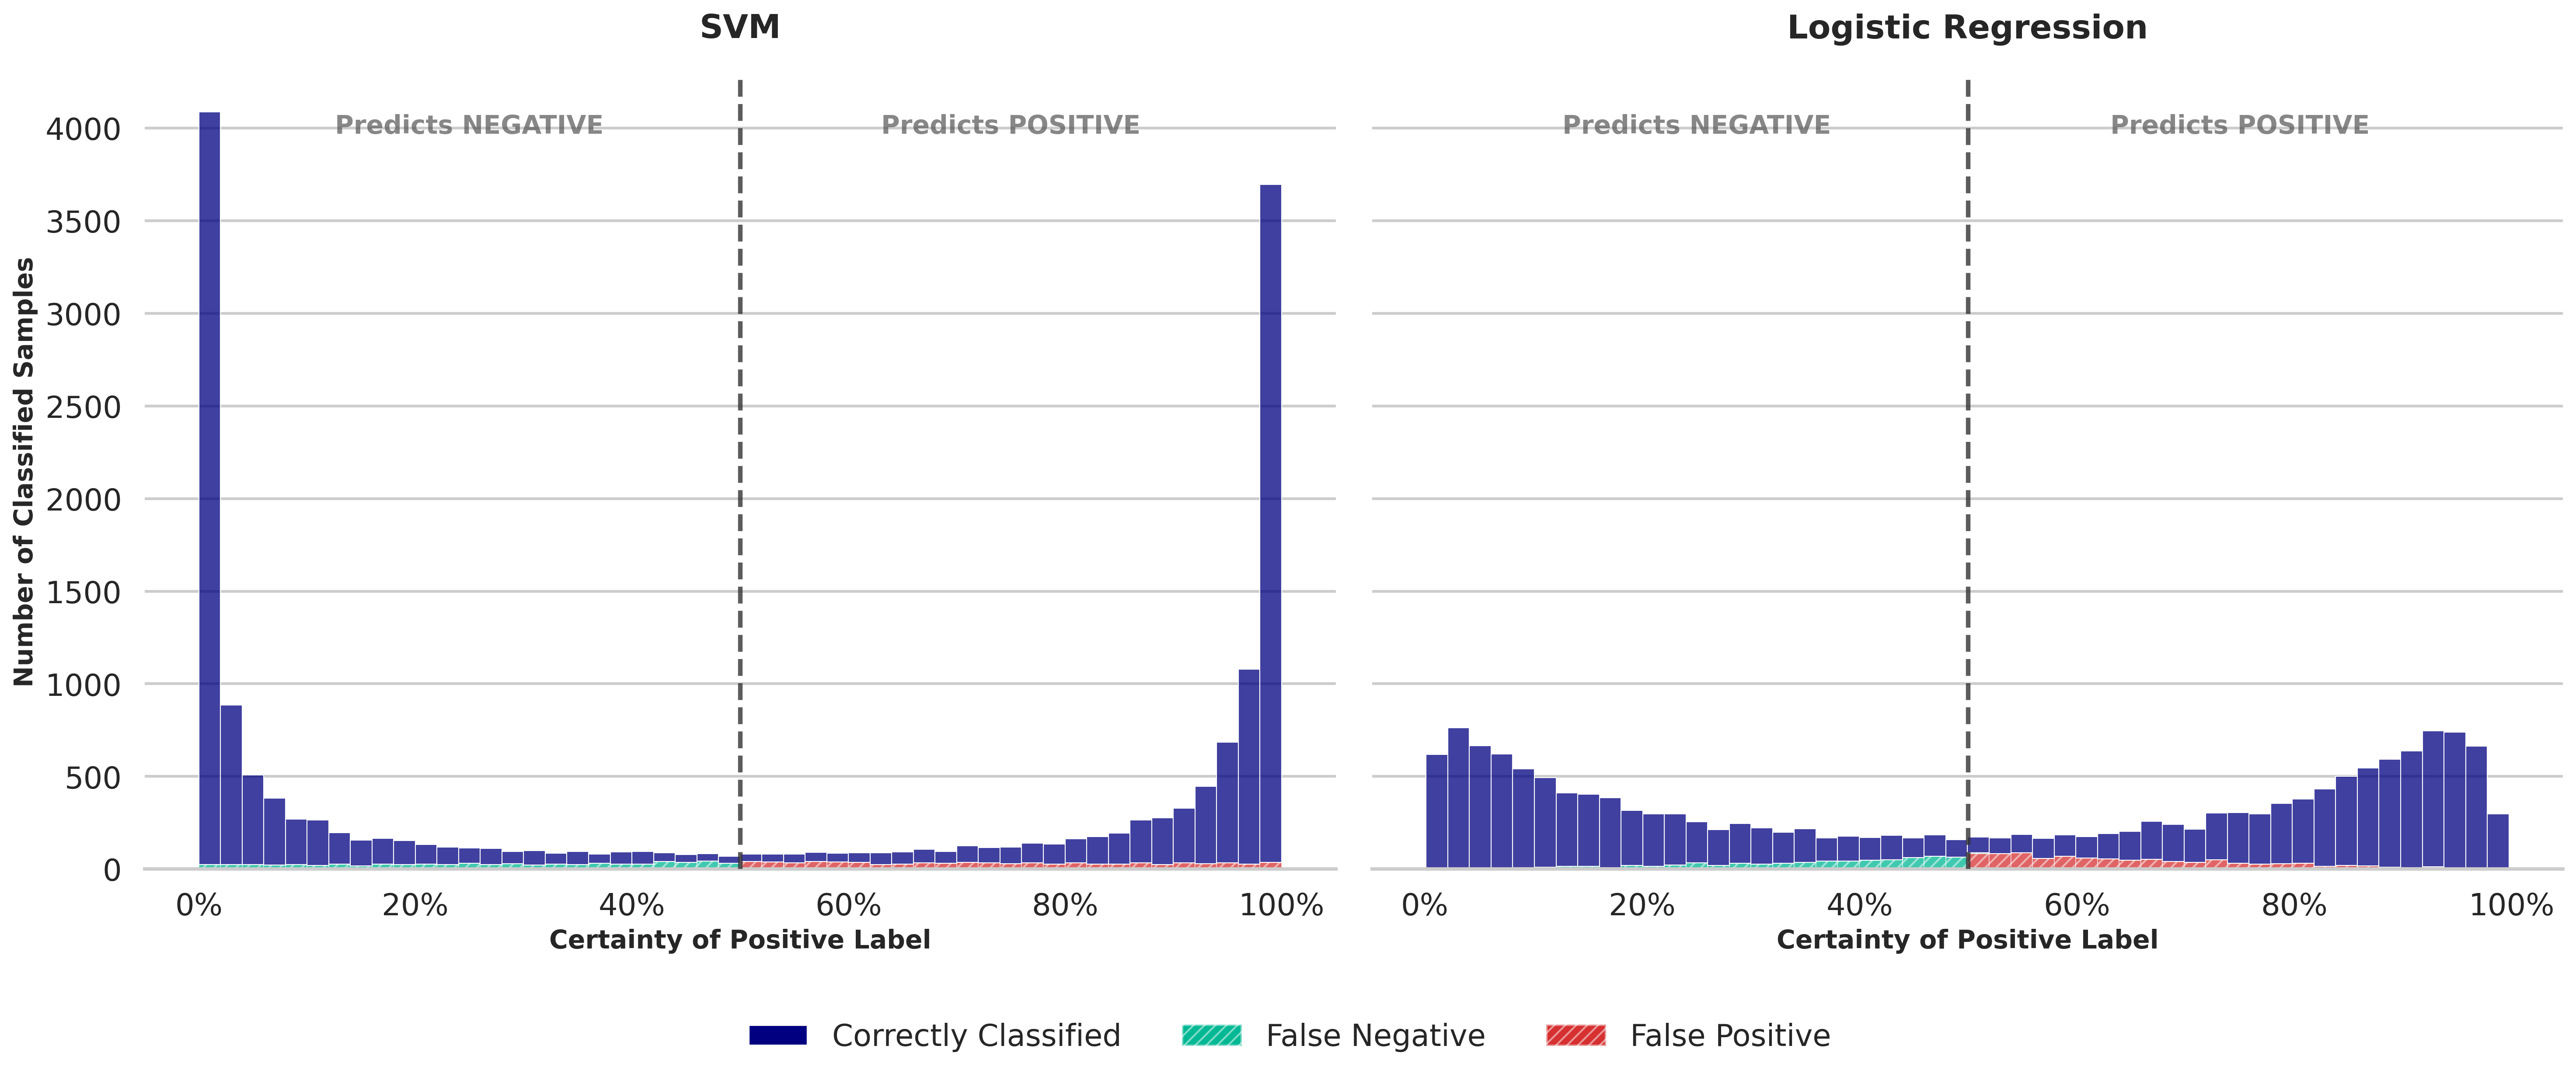

In [7]:
!python -m scripts.visualize_certainty
display(Image("results/figures/analysis/model_comparison_certainty_dist.png"))

In [17]:
import pandas as pd
import numpy as np
from pathlib import Path
from src.utils.paths import RESULTS_DIR

# ------------------------------------------------------------------
# Bin definitions (symmetric around 0.5)
# ------------------------------------------------------------------
def _assign_certainty_bin(prob: float) -> int:
    """Map a probability to one of five symmetric bins."""
    if 0.4 <= prob <= 0.6:
        return 0
    if (0.3 <= prob < 0.4) or (0.6 < prob <= 0.7):
        return 1
    if (0.2 <= prob < 0.3) or (0.7 < prob <= 0.8):
        return 2
    if (0.1 <= prob < 0.2) or (0.8 < prob <= 0.9):
        return 3
    return 4   # [0.0, 0.1) ∪ (0.9, 1.0]

BIN_LABELS = [
    r"$[0.4, 0.6]$",
    r"$[0.3, 0.4) \cup (0.6, 0.7]$",
    r"$[0.2, 0.3) \cup (0.7, 0.8]$",
    r"$[0.1, 0.2) \cup (0.8, 0.9]$",
    r"$[0.0, 0.1) \cup (0.9, 1.0]$",
]

# ------------------------------------------------------------------
# Main function – returns the LaTeX code as a string
# ------------------------------------------------------------------
def generate_certainty_table(
    experiment_name: str,
    model_filenames: list[str],
    model_display_names: list[str],
    table_caption: str = "Comparison of certainty ranges.",
    table_label: str = "tab:certainty",
    subtable_labels: list[str] | None = None,
    first_col_names: list[str] | None = None,
    error_col_label: str = r"\% of Total Error",
    base_dir: Path | None = None,
) -> str:
    """
    Build a LaTeX table with one subtable per model.
    Columns: first_col, Predictions, Correct, Incorrect,
             Local Accuracy, Workload, and % of Total Error.
    """
    if subtable_labels is None:
        subtable_labels = [f"tab:certainty_{chr(97+i)}" for i in range(len(model_filenames))]
    if first_col_names is None:
        first_col_names = ["Probability Range"] * len(model_filenames)

    # Folders
    if base_dir is None:
        base_dir = RESULTS_DIR / "val" / experiment_name / "raw_predictions"

    summaries = []
    for fname, disp_name, first_col in zip(
        model_filenames, model_display_names, first_col_names
    ):
        file_path = base_dir / fname
        if not file_path.exists():
            raise FileNotFoundError(f"File not found: {file_path}")

        df = pd.read_csv(file_path)
        df["bin"] = df["probability"].apply(_assign_certainty_bin)
        total_predictions = len(df)

        # True / False positives (probability > 0.5)
        pos_mask = df["probability"] > 0.5
        df["is_tp"] = pos_mask & (df["true_label"] == 1)
        df["is_fp"] = pos_mask & (df["true_label"] == 0)

        # False negatives (probability ≤ 0.5, true_label == 1)
        neg_mask = df["probability"] <= 0.5
        df["is_fn"] = neg_mask & (df["true_label"] == 1)

        grouped = df.groupby("bin").agg(
            Predictions=("true_label", "count"),
            TP=("is_tp", "sum"),
            FP=("is_fp", "sum"),
            FN=("is_fn", "sum"),
        )
        grouped = grouped.reindex(range(5), fill_value=0)

        # True negatives (predictions ≤ 0.5, true_label == 0)
        grouped["TN"] = grouped["Predictions"] - grouped["TP"] - grouped["FP"] - grouped["FN"]

        # Correct = TP + TN, Incorrect = FP + FN
        grouped["Correct"] = grouped["TP"] + grouped["TN"]
        grouped["Incorrect"] = grouped["FP"] + grouped["FN"]

        total_errors_all = grouped["Incorrect"].sum()

        # Local accuracy = Correct / Predictions
        grouped["Local Accuracy"] = np.where(
            grouped["Predictions"] > 0,
            grouped["Correct"] / grouped["Predictions"] * 100,
            0.0,
        )
        grouped["Workload"] = grouped["Predictions"] / total_predictions * 100
        grouped["Pct Total Error"] = np.where(
            total_errors_all > 0,
            grouped["Incorrect"] / total_errors_all * 100,
            0.0,
        )

        # Build LaTeX rows
        rows = []
        for bin_idx in range(5):
            row = grouped.loc[bin_idx]
            rows.append([
                BIN_LABELS[bin_idx],
                f"${int(row['Predictions'])}$",
                f"${int(row['Correct'])}$",
                f"${int(row['Incorrect'])}$",
                f"${row['Local Accuracy']:.2f}\\%$",
                f"${row['Workload']:.2f}\\%$",
                f"${row['Pct Total Error']:.2f}\\%$",
            ])
        summaries.append({
            "rows": rows,
            "first_col_header": first_col,
            "model_name": disp_name,
        })

    # ----- Assemble LaTeX -----
    other_headers = ["Predictions", "Correct", "Incorrect",
                     "Local Accuracy", "Workload", error_col_label]
    lines = []
    lines.append("\\begin{table}[htbp]")
    lines.append("    \\centering")
    lines.append(f"    \\caption{{{table_caption}}}")
    lines.append(f"    \\label{{{table_label}}}")

    for i, summ in enumerate(summaries):
        if i > 0:
            lines.append("")                     # blank line before
            lines.append("    \\vspace{0.5em}")
            lines.append("")                     # blank line after
        lines.append("    \\begin{subtable}{\\textwidth}")
        lines.append("        \\centering")
        lines.append(f"        \\caption{{Certainty Analysis - {summ['model_name']}}}")
        lines.append(f"        \\label{{{subtable_labels[i]}}}")
        lines.append("        \\begin{tabular}{l r r r r r r}")   # 7 columns
        lines.append("            \\toprule")
        header_cols = [summ["first_col_header"]] + other_headers
        lines.append("            " + " & ".join(header_cols) + " \\\\")
        lines.append("            \\midrule")
        for row in summ["rows"]:
            lines.append("            " + " & ".join(row) + " \\\\")
        lines.append("            \\bottomrule")
        lines.append("        \\end{tabular}")
        lines.append("    \\end{subtable}")

    lines.append("\\end{table}")
    return "\n".join(lines)


# =====================================================================
# Example usage – prints the generated LaTeX (Jupyter‑ready)
# =====================================================================
print(generate_certainty_table(
    experiment_name="run_n_grams",
    model_filenames=["ng1-3_logreg.csv", "ng1-3_linear_svm.csv"],
    model_display_names=[r"\logreg", "SVM"],
    table_caption="Comparison of certainty ranges.",
    table_label="tab:certainty",
    subtable_labels=["tab:certainty_lr", "tab:certainty_svm"],
    first_col_names=["Probability Range", "Certainty Range"],
))

\begin{table}[htbp]
    \centering
    \caption{Comparison of certainty ranges.}
    \label{tab:certainty}
    \begin{subtable}{\textwidth}
        \centering
        \caption{Certainty Analysis - \logreg}
        \label{tab:certainty_lr}
        \begin{tabular}{l r r r r r r}
            \toprule
            Probability Range & Predictions & Correct & Incorrect & Local Accuracy & Workload & \% of Total Error \\
            \midrule
            $[0.4, 0.6]$ & $1747$ & $1066$ & $681$ & $61.02\%$ & $10.07\%$ & $42.12\%$ \\
            $[0.3, 0.4) \cup (0.6, 0.7]$ & $2080$ & $1637$ & $443$ & $78.70\%$ & $11.99\%$ & $27.40\%$ \\
            $[0.2, 0.3) \cup (0.7, 0.8]$ & $2803$ & $2508$ & $295$ & $89.48\%$ & $16.15\%$ & $18.24\%$ \\
            $[0.1, 0.2) \cup (0.8, 0.9]$ & $4524$ & $4364$ & $160$ & $96.46\%$ & $26.07\%$ & $9.89\%$ \\
            $[0.0, 0.1) \cup (0.9, 1.0]$ & $6199$ & $6161$ & $38$ & $99.39\%$ & $35.72\%$ & $2.35\%$ \\
            \bottomrule
        \end{tabular}
    \e

# BERT

In [87]:
!python -m scripts.train_bert --config configs/default.yaml


>>> Training Basic BERT Baseline <<<
I0000 00:00:1773333876.461948    9588 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3584 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6
TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.
All PyTorch model weights were used when initializing TFDistilBertForSequenceClassification.

All the weights of TFDistilBertForSequenceClassification were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFDistilBertForSequenceClassification for predictions without further training.
Epoch 1/3
I0000 00:00:1773333957.151189    9624 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
1240/1240 [==


Sweeping Certainty Thresholds for Exact Hybrid Optimization...
Auto-saved optimal configuration to best_params.yaml

CASCADE OPTIMIZATION WINNER: tokens_stemmed_CustomTfidf_Z0_linear_svm
-> Peak Global System Accuracy: 93.09% (Beats Base BERT by +1.82%)
-> Required Model Certainty: 77.1% (Accepts probs >= 0.771 or <= 0.229)
-> Data Delegated to BERT: 15.17% (Base model handles 84.83%)

Saved SVM Trade-off graphs to: /home/janek/Projekty/Sentiment/results/figures/analysis/svm_accuracy_coverage_tradeoff.png
<IPython.core.display.Image object>
Saved LogReg Trade-off graphs to: /home/janek/Projekty/Sentiment/results/figures/analysis/logreg_accuracy_coverage_tradeoff.png
<IPython.core.display.Image object>


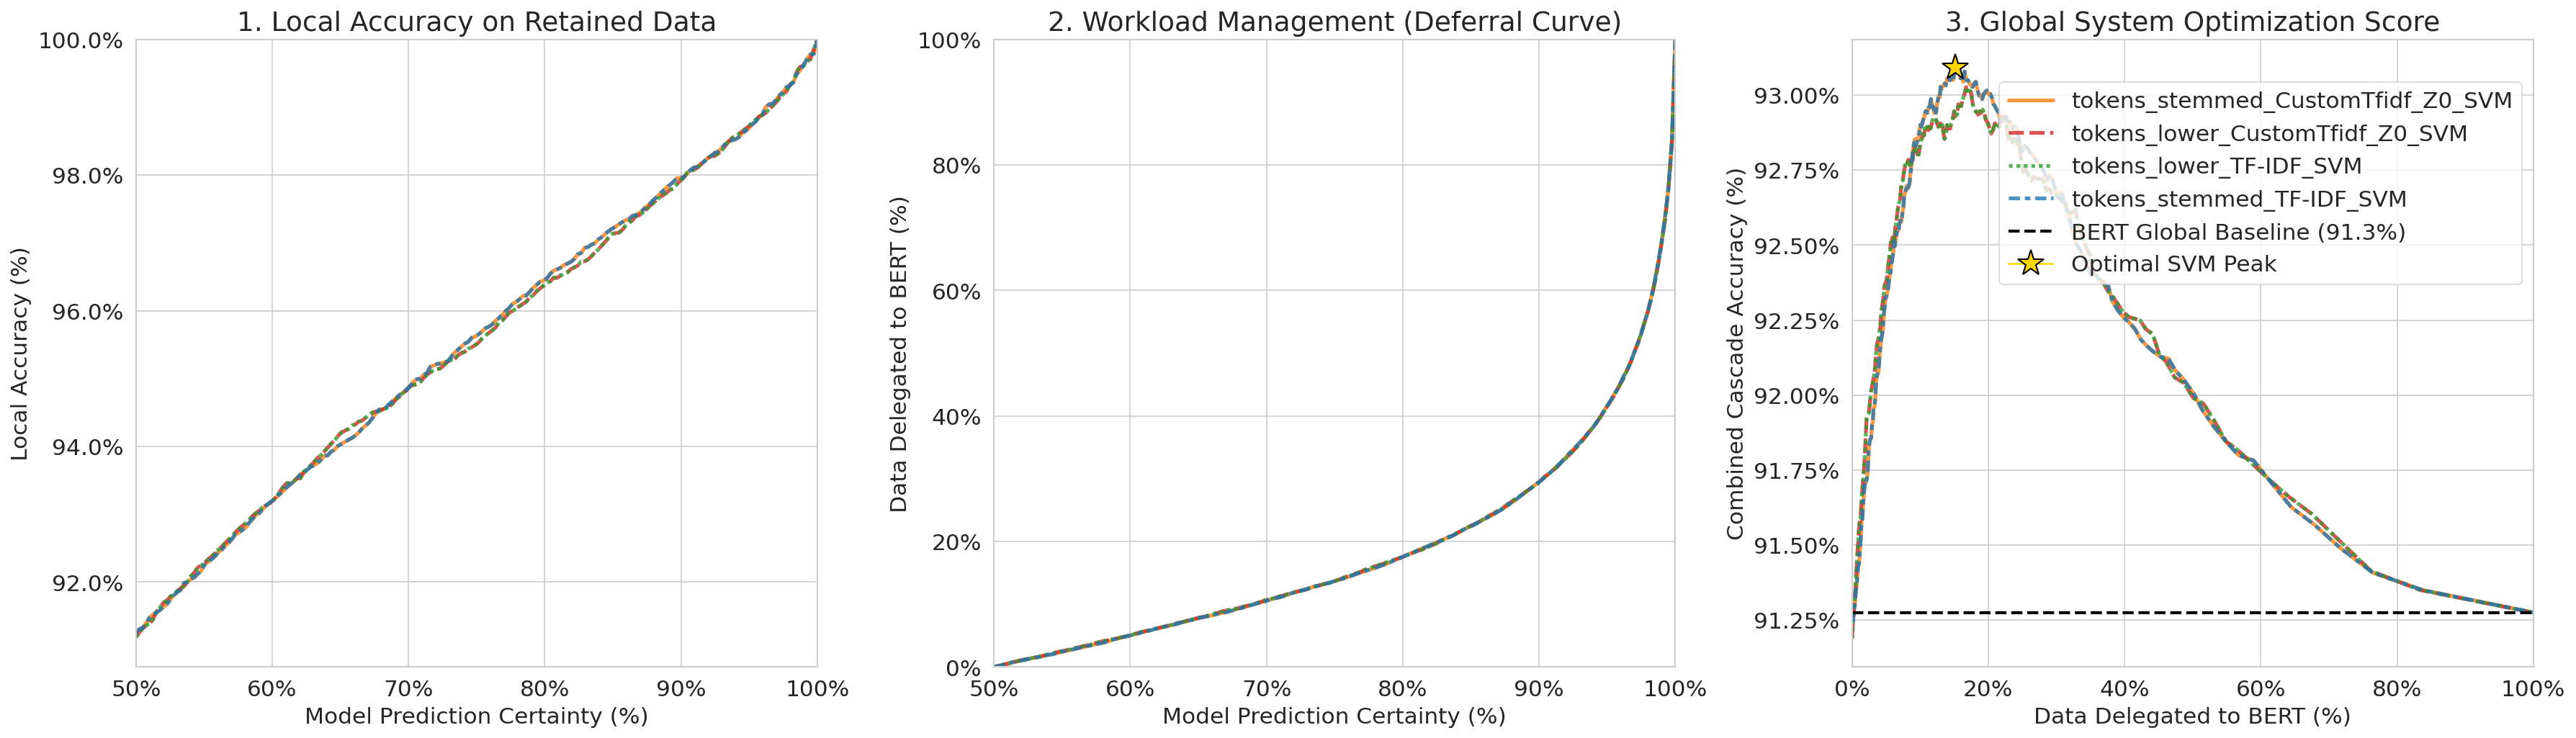

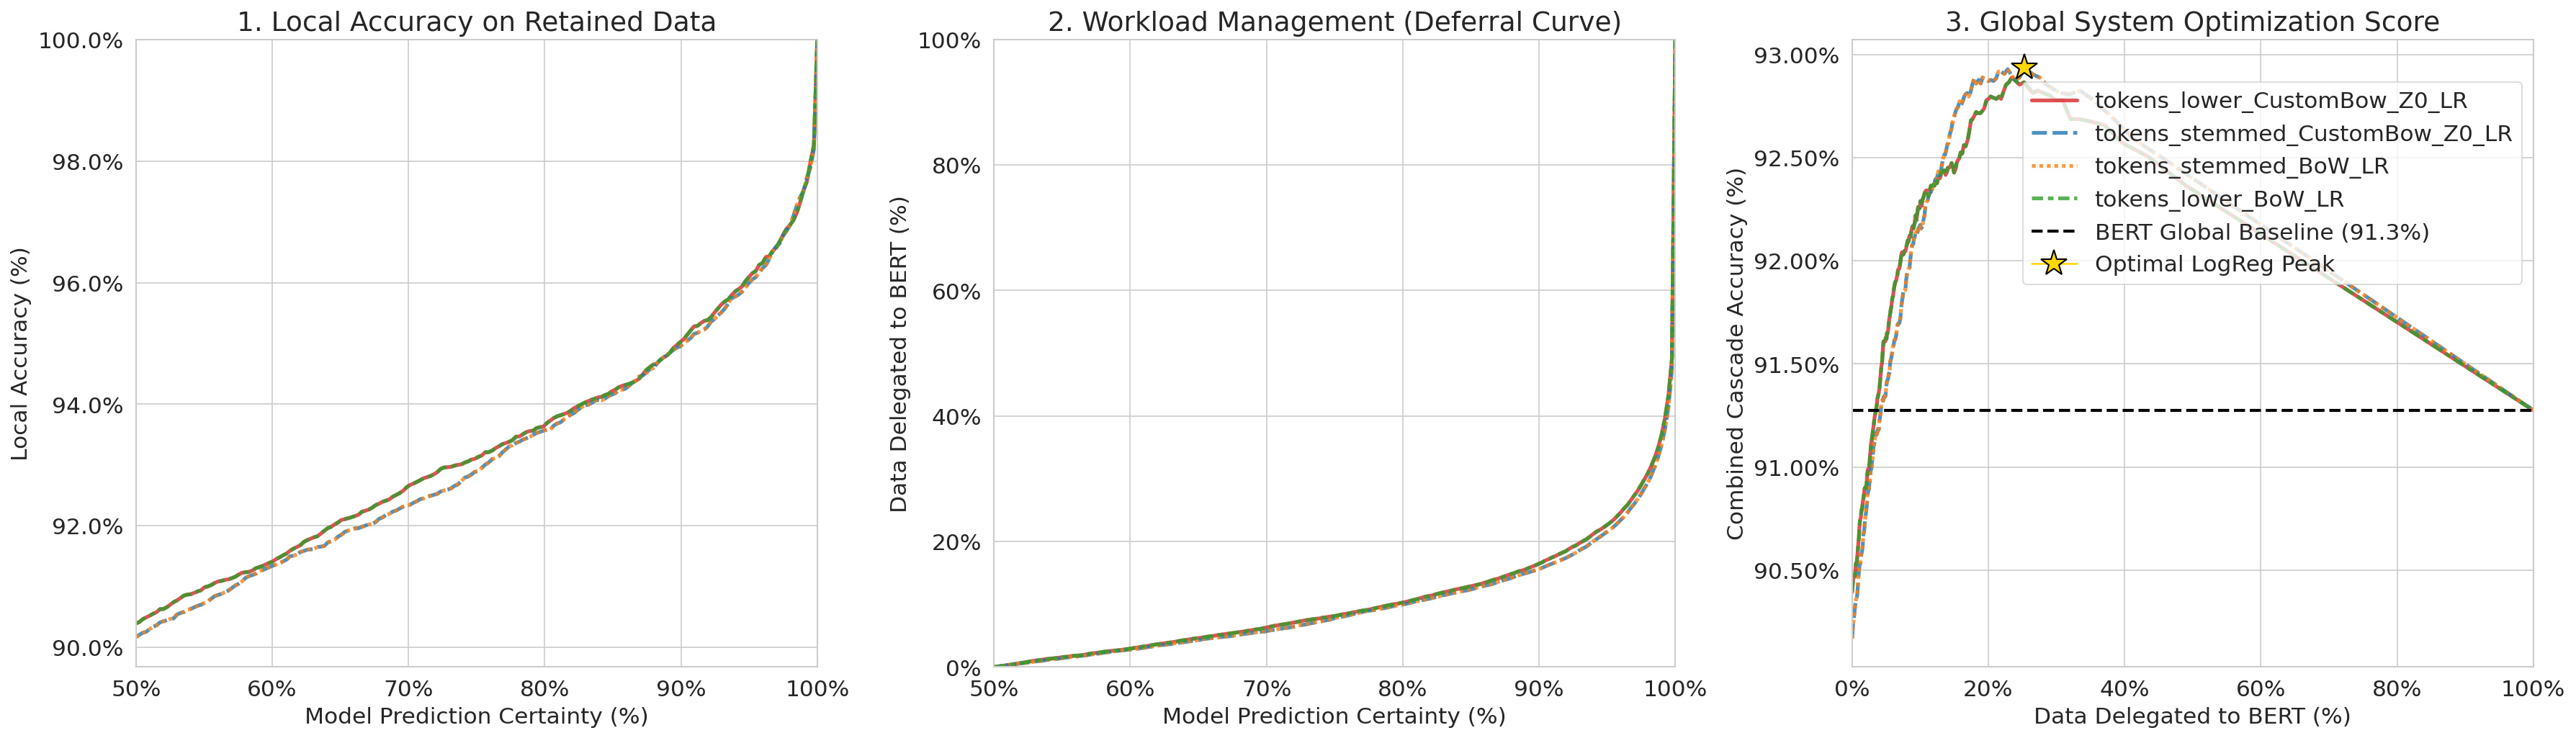

In [31]:
!python -m scripts.analyse_results
display(Image("results/figures/analysis/svm_accuracy_coverage_tradeoff.png"))
display(Image("results/figures/analysis/logreg_accuracy_coverage_tradeoff.png"))

In [42]:
!python -m scripts.train_specialist_SVM

2026-03-31 16:38:13.135460: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/janek/Projekty/Sentiment/.venv/lib/python3.12/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):
Loading sparse data using token column: 'tokens_stemmed'...
Applying TF-IDF...

Training base model (linear_svm) with best parameters...
Base model saved to /home/janek/Projekty/Sentiment/models/svm_base

Mining hard samples from the TRAIN and VALIDATION sets...
Train hard samples found: 654 (2.64%)
Validation hard samples found: 2326 (13.40%)

Training SVM Specialist on 2326 validation hard samples...
SVM Specialist trained and saved. Hard sample indices sav

In [40]:
import numpy as np
import pandas as pd
import gc
from pathlib import Path

def preview_hard_samples_memory_safe(filepath, file, n=3, text_chars=200):
    hard_indices = np.load(Path("models") / file)
    
    df = pd.read_parquet(filepath, columns=['sentiment', 'text_clean'])
    df_hard = df.iloc[hard_indices]

    print(f"\nFile: {filepath}")
    print(f"Total hard samples available: {len(df_hard)}")
    print(f"Showing first {n} hard samples...\n")

    df_sample = df_hard.head(n)

    for i, (original_idx, row) in enumerate(df_sample.iterrows()):
        sentiment = row['sentiment']
        text = str(row['text_clean'])
        
        # Truncate text if needed
        preview = text[:text_chars] + (" ..." if len(text) > text_chars else "")
        
        print(f"--- Hard Sample {i + 1} (Original Row: {original_idx}) ---")
        print(f"[Sentiment: {sentiment}] {preview}\n")

    del df, df_hard, df_sample
    gc.collect()

# Run the preview
preview_hard_samples_memory_safe('data/preprocessed/train.parquet', "hard_indices_train.npy", n=5)
preview_hard_samples_memory_safe('data/preprocessed/val.parquet', "hard_indices_val.npy", n=5)


File: data/preprocessed/train.parquet
Total hard samples available: 654
Showing first 5 hard samples...

--- Hard Sample 1 (Original Row: 1) ---
[Sentiment: 0] I first watched Kindred in 1987 along with another movie called devouring waves. I remember back then i hated them both and i have never really bothered to watch them again. However i have recently st ...

--- Hard Sample 2 (Original Row: 26) ---
[Sentiment: 0] I saw Winnie's Heffalump a couple of days ago. A nice story based on well known characters created by A.A.Milne. Although Winnie, Piglet, Tigger and Rabbit are all present in this animated feature, th ...

--- Hard Sample 3 (Original Row: 32) ---
[Sentiment: 1] the photography was beautiful but i had difficulty understanding what was happening... was there a lot of symbolism?... the 2 goldfishes - do they mean something in Thai culture? there's not much plot ...

--- Hard Sample 4 (Original Row: 63) ---
[Sentiment: 1] This entertainingly tacky'n'trashy distaff "Death Wis

In [48]:
!python -m scripts.train_specialist_BERT

Loading data for hard sample mining...
Loading raw text data...

Loading base model from /home/janek/Projekty/Sentiment/models/svm_base...
Mining hard samples from the validation set...
Validation hard samples found: 2326 (13.40%)

Loading and evaluating Basic BERT on test set...
I0000 00:00:1774968853.911345    3900 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3584 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6
Basic BERT evaluated.

Fine-tuning BERT Specialist on hard validation samples...
Epoch 1/10
I0000 00:00:1774968952.683200    3936 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
117/117 [==============================] - 35s 220ms/step - loss: 0.6307 - accuracy: 0.6989 - val_loss: 0.6146 - val_accuracy: 0.6974 - lr: 2.0000e-06
Epoch 2/10
117/117 [==============================] - 22s 184ms/step - los

In [63]:
!python -m scripts.run_ensemble

--- Processing Cascades (Threshold: 0.254) ---
Saved results for: SVM_Spec_Cascade
Saved results for: BERT_Basic_Cascade
Saved results for: BERT_Spec_Cascade


Significant: Base + Basic BERT (p=0.0001)
Significant: Base + Spec. BERT (p=0.0001)
Significant: Base + Spec. SVM (p=0.0008)
Significant: BERT Basic (p=0.0000)
Wykres zapisany w: results/figures/thesis/cascade_comparison_f1_macro.png


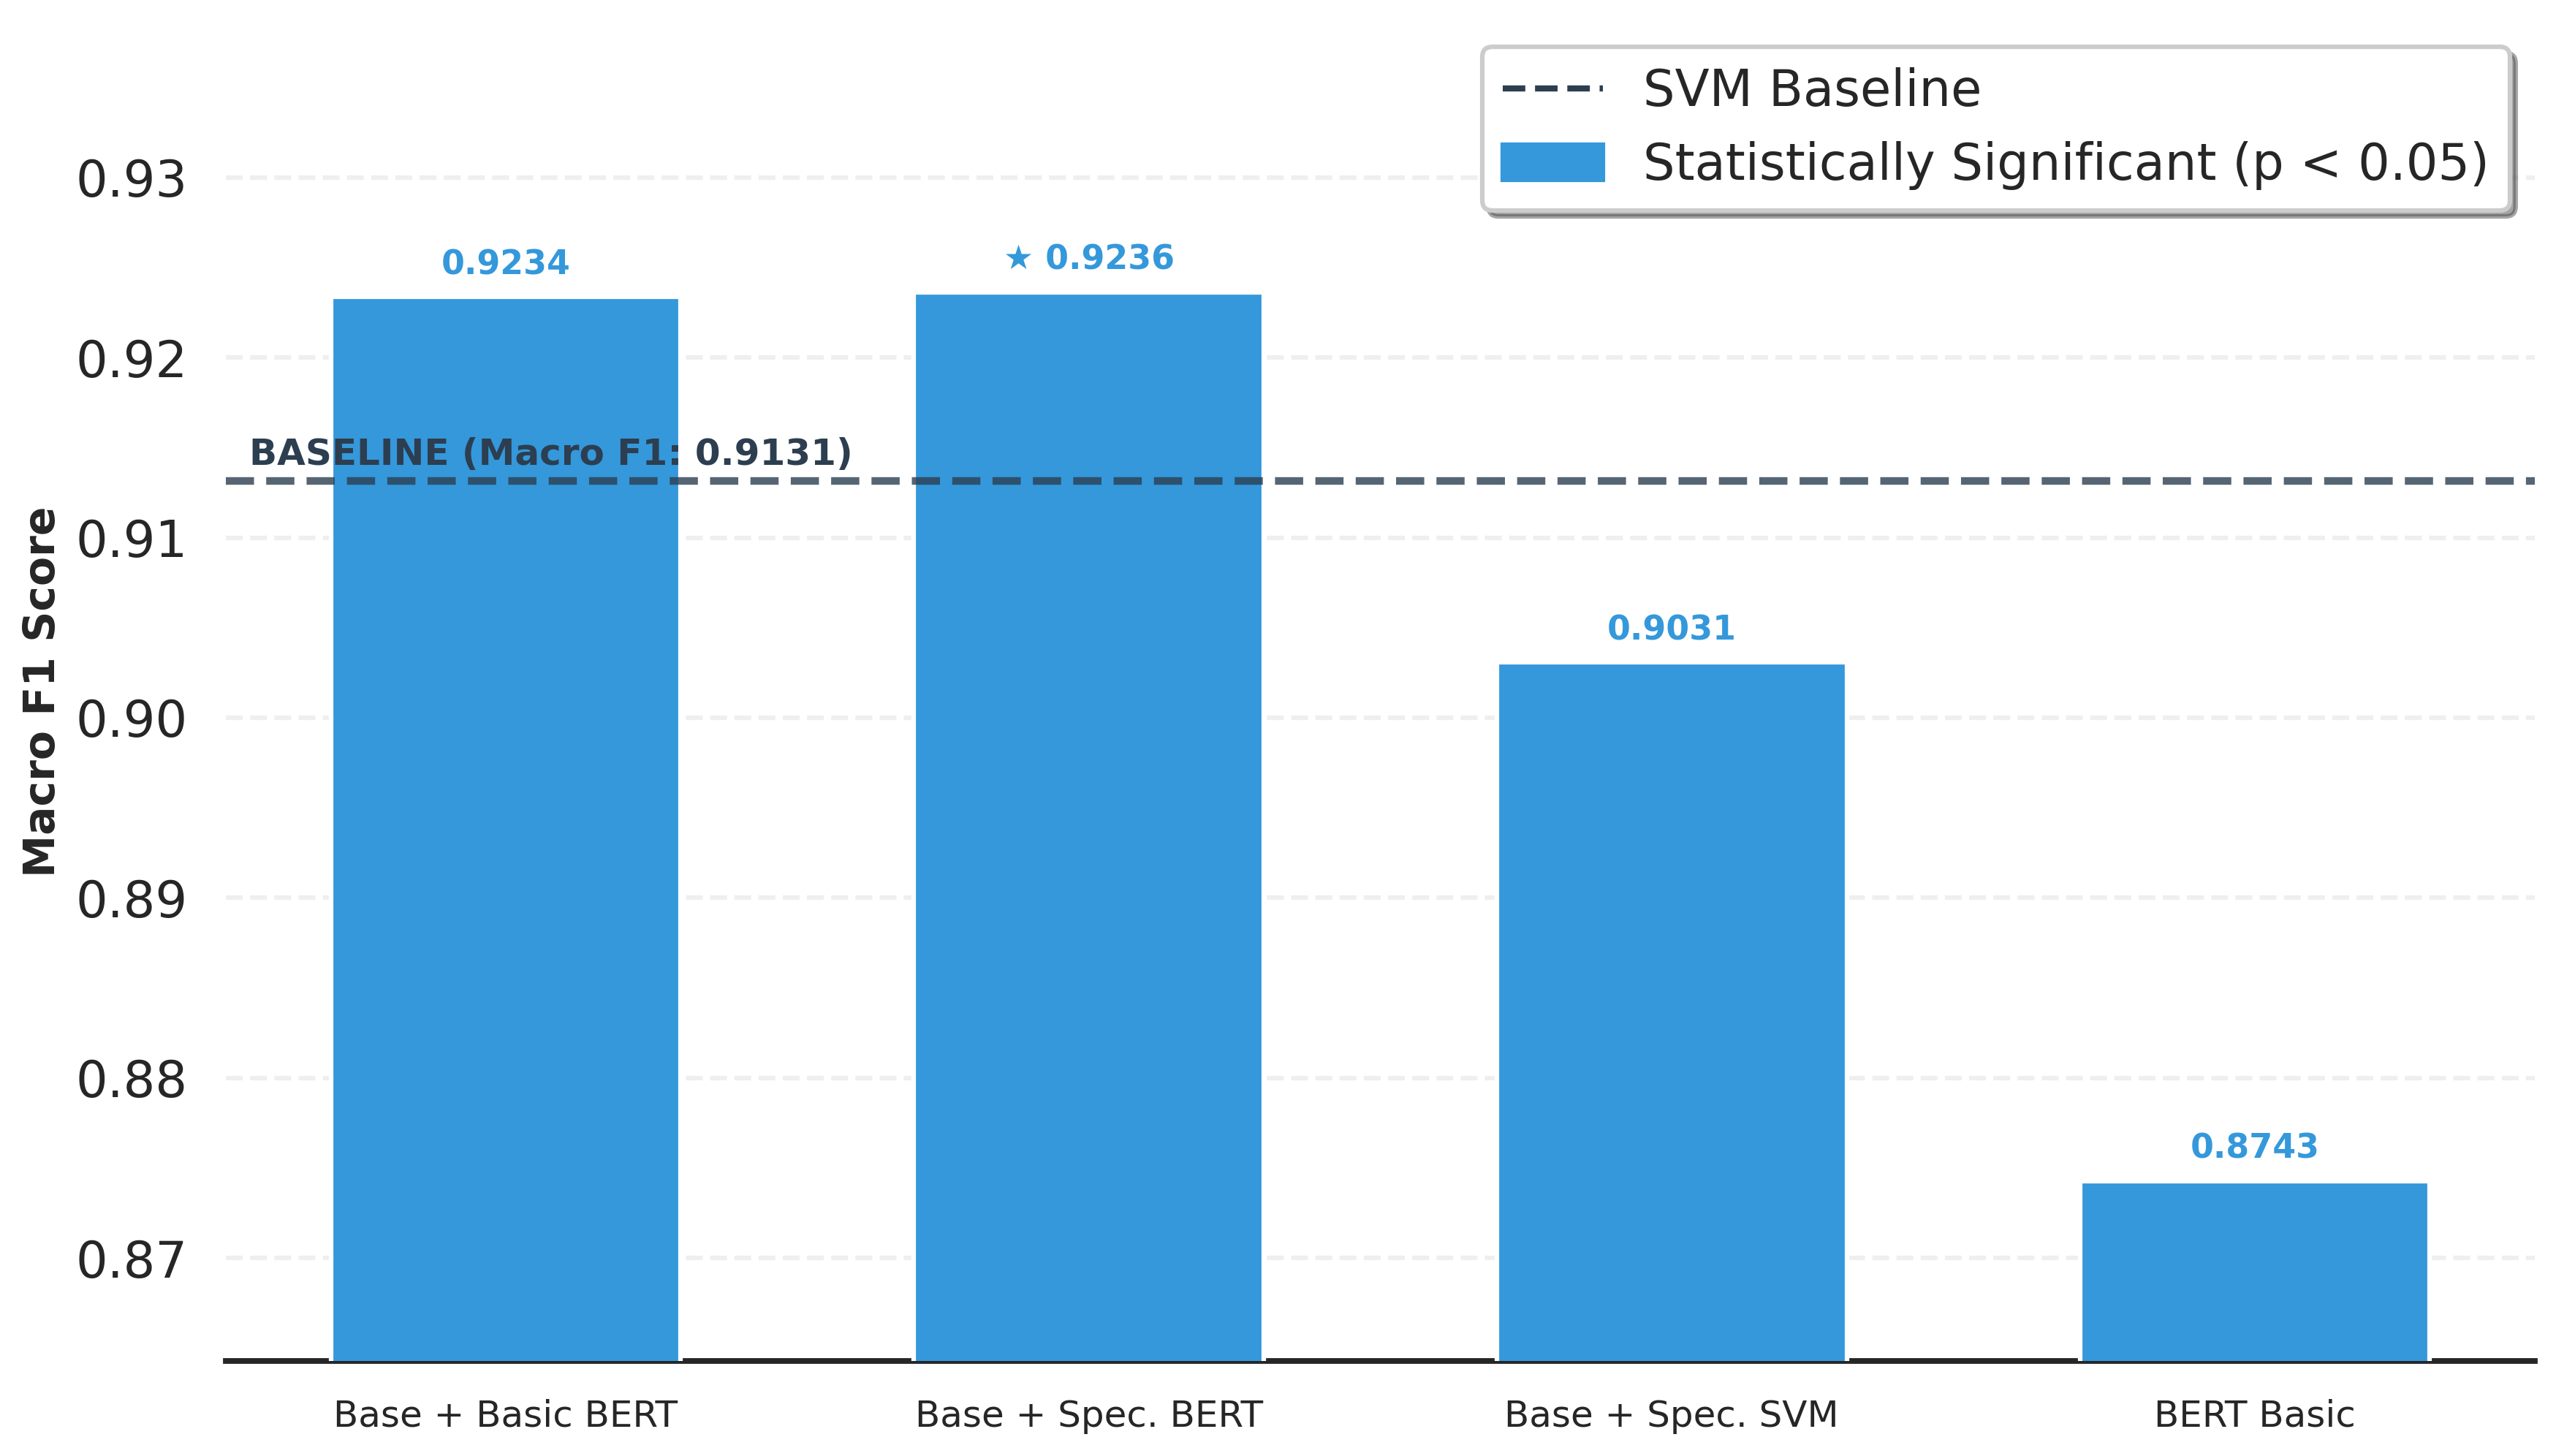

In [4]:
!python -m scripts.visualize_thesis
display(Image("results/figures/thesis/cascade_comparison_f1_macro.png"))

In [55]:
!python -m scripts.run_statistical_test \
    --split test \
    --targets "::BERT_Spec_Cascade" \
    --baseline test/raw_predictions/BERT_Basic_Cascade.csv \
    --output cascade_mcnemar_raport_BERT.csv

pokaz_wyniki_mcnemara("results/analysis/cascade_mcnemar_raport_BERT.csv")

,Text,Representation,Model,Acc_Model,Better,P_Value
0,txt,rep,name,92.34%,,Baseline
1,nan,nan,BERT_Spec_Cascade,92.36%,,0.859684



--- Kod LaTeX ---
\begin{table}[htbp]
    \centering
\caption{McNemar test}
\label{tab:McNemar}
\begin{tabular}{llllrcc}
\toprule
 & Text & Representation & Model & $Acc_{Model}$ & $\uparrow$/$\downarrow$ & $p$-value \\
\midrule
\textbf{0} & \textbf{txt} & \textbf{rep} & \textbf{name} & \textbf{92.34\%} & \textbf{} & \textbf{Baseline} \\
1 & nan & nan & BERT_Spec_Cascade & 92.36\% &  & 0.859684 \\
\bottomrule
\end{tabular}
\end{table}



Saved confusion matrix plot to: /home/janek/Projekty/Sentiment/results/figures/thesis/all_models_hard_cases_cm.png


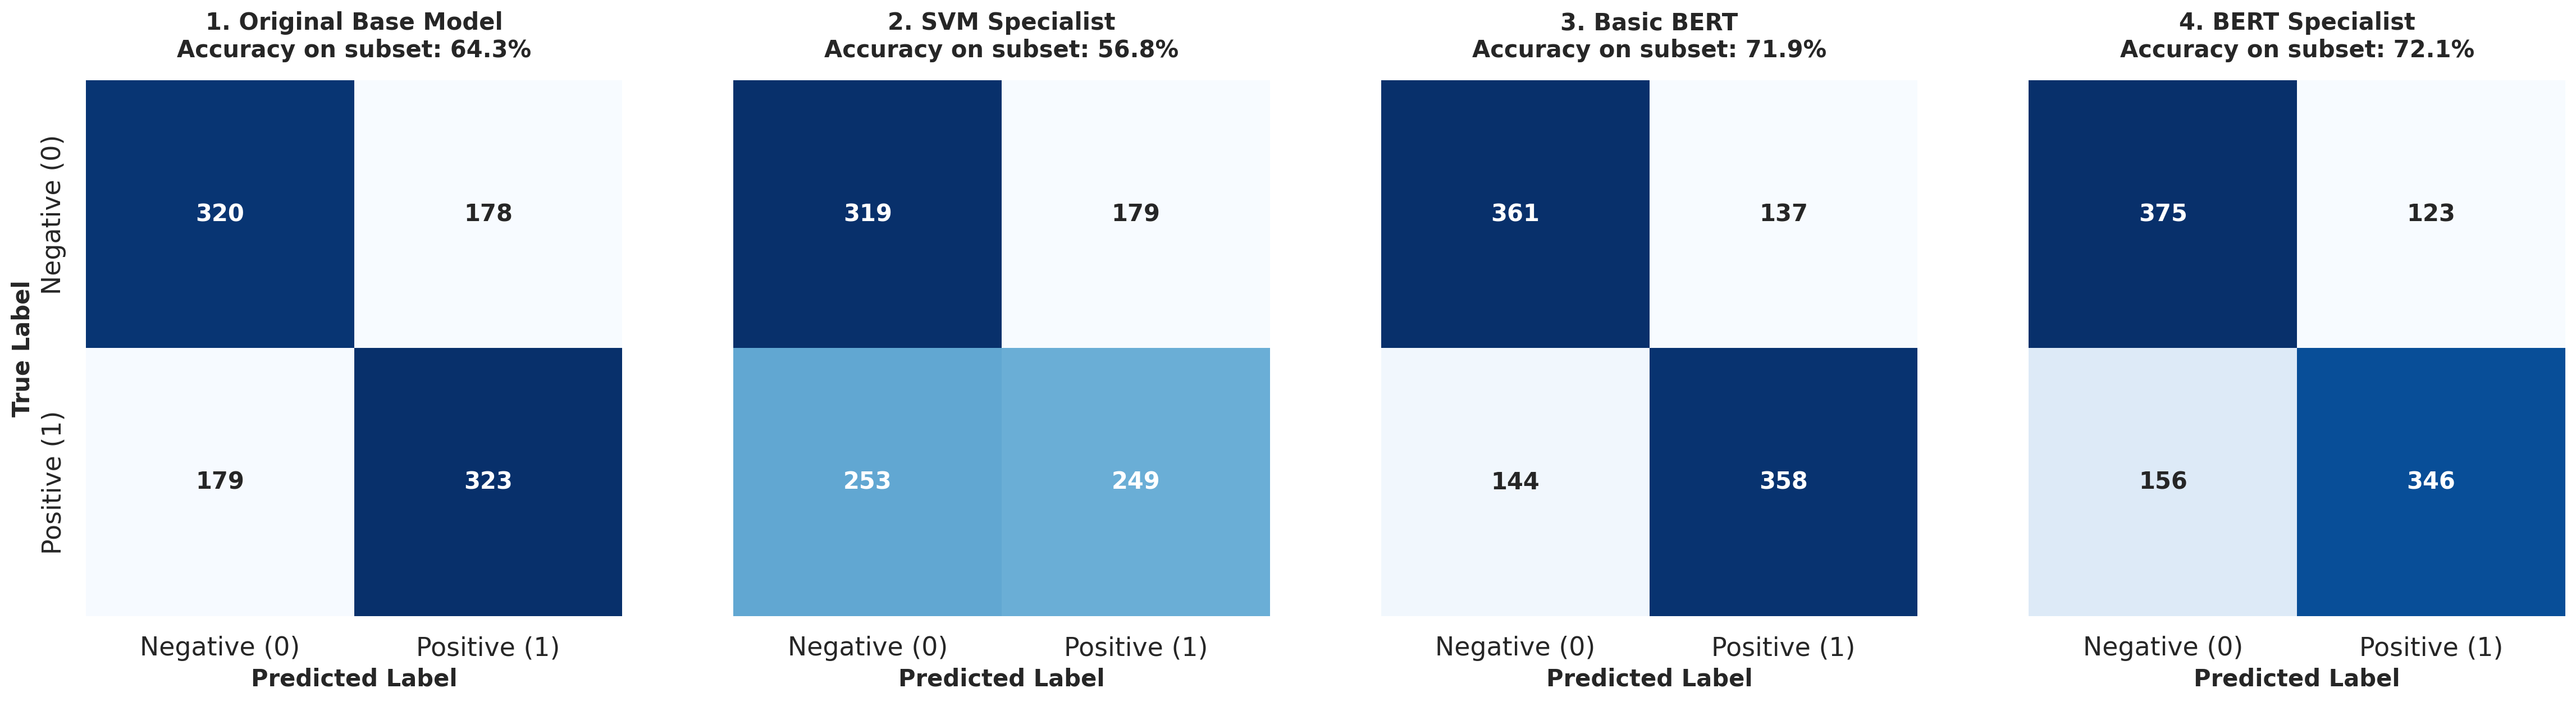

In [24]:
!python -m scripts.visualize_specialists
display(Image("results/figures/thesis/all_models_hard_cases_cm.png"))

In [25]:
import pandas as pd
import numpy as np
import yaml
from src.utils.paths import PROJECT_ROOT, DATA_DIR, RESULTS_DIR

# Setup & Config (Threshold)
with open(PROJECT_ROOT / "configs/best_params.yaml") as f:
    cfg = yaml.safe_load(f)

threshold = cfg.get('cascade', {}).get('delegation_threshold', 0.15)
lower, upper = threshold, 1.0 - threshold

# Load Data and Predictions
df_test = pd.read_parquet(DATA_DIR / "preprocessed" / "test.parquet")
df_base = pd.read_csv(RESULTS_DIR / "test" / "raw_predictions" / "Base_SVM.csv")
df_spec = pd.read_csv(RESULTS_DIR / "test" / "raw_predictions" / "BERT_Specialist.csv")

# Create DataFrame
analysis = pd.DataFrame({
    'text': df_test['text_clean'].values,
    'label': df_test['sentiment'].values,
    'p_base': df_base['probability'].values,
    'p_spec': df_spec['probability'].values
})

# Cascade Logic
analysis['is_delegated'] = (analysis['p_base'] >= lower) & (analysis['p_base'] <= upper)
analysis['final_prob'] = np.where(analysis['is_delegated'], analysis['p_spec'], analysis['p_base'])
analysis['final_pred'] = (analysis['final_prob'] > 0.5).astype(int)
analysis['is_correct'] = analysis['final_pred'] == analysis['label']

# Categorization Logic
conditions = [
    (analysis['is_delegated'] & analysis['is_correct']),
    (analysis['is_delegated'] & ~analysis['is_correct']),
    (~analysis['is_delegated'] & analysis['is_correct']),
    (~analysis['is_delegated'] & ~analysis['is_correct'])
]
choices = ['RESOLVED_BY_SPEC', 'FAILED_BY_SPEC', 'BASE_SUCCESS', 'BASE_HIDDEN_FAILURE']
analysis['cascade_category'] = np.select(conditions, choices, default='UNKNOWN')

# Specialist Certainty Error
analysis['spec_error_mag'] = np.where(
    analysis['is_delegated'], 
    abs(analysis['p_spec'] - analysis['label']), 
    0
)
# Base Certainty Error
analysis['base_error_mag'] = np.where(
    ~analysis['is_delegated'], 
    abs(analysis['p_base'] - analysis['label']), 
    0
)

# Final Sorting and Save
final_output = analysis.sort_values(
    ['cascade_category', 'spec_error_mag', 'base_error_mag'],
    ascending=[True, False, False]
)

out_path = RESULTS_DIR / "thesis" / "cascade_qualitative_analysis.csv"
(RESULTS_DIR / "thesis").mkdir(parents=True, exist_ok=True)
final_output.to_csv(out_path, index=False)